Necessary Libraries

In [22]:
import os
import numpy as np
import pandas as pd

import nltk
import nltk.tokenize as tk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


from sklearn.datasets import load_files
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import re


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


#  Part A – Data Preparation

## Load the dataset 

In [23]:
dataset = load_files('./content/30Columnists/raw_texts', encoding='cp1252')

dataset.data

['Shares in Burberry slumped more than 10% today as the luxury goods group admitted its sales had fallen short of target over Christmas.\r\n\r\nAlthough overall revenues were up by 26% in the three months to the end of December, chief executive Angela Ahrendts said sales on the retail side came in "modestly behind our plan," which meant more stock was sold at reduced prices during its sale.\r\n\r\nUnderlying retail sales were up by 6%. On the wholesale side, revenues jumped by 74% and the group now expects growth of 20% for the second half, up from its previous forecast of mid-teens.\r\n\r\nAhrendts said the performance reflected the "continued appeal" of new products at the group, which is still best-known for its distinctive check pattern.\r\n\r\nLuxury handbags, outerwear, shoes and other accessories, including scarves, were particularly strong. In Europe, Italy was the best-performing market.\r\n\r\nShares in the group slumped 52.7p to 433.75p in early trading today as analysts tri

In [24]:
print("--- Dataset ---")


print(f"Total Text: {len(dataset.data)}")
print("-" * 35)

print(f"Total Author(Class) Count: {len(dataset.target_names)}")
print(f"Author IDs (target_names): {dataset.target_names}")
print("-" * 35)

--- Dataset ---
Total Text: 1500
-----------------------------------
Total Author(Class) Count: 30
Author IDs (target_names): ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '4', '5', '6', '7', '8', '9']
-----------------------------------


In [25]:
df = pd.DataFrame(dataset.data)


df['author_id'] = [dataset.target_names[i] for i in dataset.target]

print("--- Basic DataFrame First 5 Rows ---")
df.head()

--- Basic DataFrame First 5 Rows ---


,0,author_id
0,Shares in Burberry slumped more than 10% today...,18
1,IT'S hard to walk into a high street shop thes...,1
2,Being lonely is as bad for your health as smok...,9
3,The Rawnsley family spent their most recent su...,10
4,A hair opinion poll sounds like the sort of tr...,8


## Text Preprocessing

In [26]:
def preprocessing(data_list, remove_stopwords=False, use_lemmatizer=False):
    clean_texts = []
    stop_words_set = set(stopwords.words('english')) if remove_stopwords else None
    lemmatizer = WordNetLemmatizer() if use_lemmatizer else None
    
    for text in data_list:
        if isinstance(text, bytes):
            text = text.decode('utf-8', errors='ignore')
        
        # Hex karakterleri temizle
        text = re.sub(r'\\x[0-9a-fA-F]+', '', text)
        
        # Noktalama işaretlerini koru (bazı yazarlar özel noktalama kullanabilir)
        text = text.lower()
        
        # Fazla boşlukları temizle
        text = text.replace('\r\n', ' ').replace('\n', ' ')
        text = re.sub(r'\s+', ' ', text).strip()
        
        # Sayıları kaldır (genellikle yazar stilini etkilemez)
        text = re.sub(r'\d+', '', text)
        
        tokens = word_tokenize(text, language='english')
        
        # Çok kısa tokenleri filtrele
        tokens = [t for t in tokens if len(t) > 2]
        
        if remove_stopwords:
            tokens = [t for t in tokens if t not in stop_words_set]
            
        if use_lemmatizer:
            tokens = [lemmatizer.lemmatize(t) for t in tokens]
            
        clean_texts.append(" ".join(tokens))
        
    return clean_texts

# Part B – Feature Engineering

In [27]:
def vectorize_texts_1gram(train_texts, test_texts, max_features=10000):

    vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=(1, 1), 
        min_df=2,  # En az 2 dokümanda geçmeli
        max_df=0.8,  # Maksimum %80 dokümanda geçebilir
        sublinear_tf=True  # Logaritmik TF scaling
    )
    
    X_train_vectorized = vectorizer.fit_transform(train_texts)
    
    X_test_vectorized = vectorizer.transform(test_texts)
        
    return vectorizer, X_train_vectorized, X_test_vectorized

In [28]:
def vectorize_texts_2gram(train_texts, test_texts, max_features=10000):

    vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=(2, 2), 
        min_df=2,  # En az 2 dokümanda geçmeli
        max_df=0.8,  # Maksimum %80 dokümanda geçebilir
        sublinear_tf=True  # Logaritmik TF scaling
    )
    
    X_train_vectorized = vectorizer.fit_transform(train_texts)
    
    X_test_vectorized = vectorizer.transform(test_texts)
        
    return vectorizer, X_train_vectorized, X_test_vectorized

In [29]:
def vectorize_texts_1_2gram(train_texts, test_texts, max_features=10000):

    vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=(1, 2), 
        min_df=2,  # En az 2 dokümanda geçmeli
        max_df=0.8,  # Maksimum %80 dokümanda geçebilir
        sublinear_tf=True  # Logaritmik TF scaling
    )
    
    X_train_vectorized = vectorizer.fit_transform(train_texts)
    
    X_test_vectorized = vectorizer.transform(test_texts)
        
    return vectorizer, X_train_vectorized, X_test_vectorized

In [30]:
def vectorize_texts_char(train_texts, test_texts, max_features=10000):

    vectorizer = TfidfVectorizer(
        max_features=max_features,
        analyzer='char',
        ngram_range=(3, 5), 
        min_df=2,  # En az 2 dokümanda geçmeli
        max_df=0.8,  # Maksimum %80 dokümanda geçebilir
        sublinear_tf=True  # Logaritmik TF scaling
    )
    
    X_train_vectorized = vectorizer.fit_transform(train_texts)
    
    X_test_vectorized = vectorizer.transform(test_texts)
        
    return vectorizer, X_train_vectorized, X_test_vectorized

In [31]:
def train_and_evaluate_model(model, X_train, y_train, X_test, y_test):
    # Modeli Eğitme
    model.fit(X_train, y_train)
    
    # Tahmin Etme
    y_pred = model.predict(X_test)
    
    # Classification Report
    print(f"--- {type(model).__name__} Results ---")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    # Confusion Matrix hesapla
    cm = confusion_matrix(y_test, y_pred)
    
    # Accuracy hesapla ve göster
    accuracy = np.trace(cm) / np.sum(cm)
    print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")
    
    # Confusion Matrix görselleştir
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=range(30), yticklabels=range(30),
                cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix - {type(model).__name__}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

#  Part C – Modeling

In [32]:
# Stratified split - her yazardan eşit oranda
train_indexes, test_indexes = train_test_split(
    range(len(dataset.data)),
    test_size=0.3,  # %30 test
    stratify=dataset.target,  # Her yazardan eşit oran
    random_state=42  # Tekrarlanabilirlik için
)

# *** BU SATIRLARI EKLEYİN ***
X_train = [dataset.data[i] for i in train_indexes]
X_test = [dataset.data[i] for i in test_indexes]
y_train = [dataset.target[i] for i in train_indexes]
y_test = [dataset.target[i] for i in test_indexes]

print(f"Train size: {len(train_indexes)}, Test size: {len(test_indexes)}")

# Bu satırlar gereksiz, y_train ve y_test zaten var:
# train_labels = [dataset.target[i] for i in train_indexes]
# test_labels = [dataset.target[i] for i in test_indexes]

print("\n### Test Set Distribution per Author ###")
unique_authors = np.unique(dataset.target)
for author_id in unique_authors:
    author_name = dataset.target_names[author_id]
    test_count = y_test.count(author_id)  # test_labels yerine y_test
    train_count = y_train.count(author_id)  # train_labels yerine y_train
    total_count = list(dataset.target).count(author_id)
    test_percentage = (test_count / total_count * 100) if total_count > 0 else 0
    print(f"{author_name}: Train={train_count}, Test={test_count} ({test_percentage:.1f}%), Total={total_count}")


Train size: 1050, Test size: 450

### Test Set Distribution per Author ###
1: Train=35, Test=15 (30.0%), Total=50
10: Train=35, Test=15 (30.0%), Total=50
11: Train=35, Test=15 (30.0%), Total=50
12: Train=35, Test=15 (30.0%), Total=50
13: Train=35, Test=15 (30.0%), Total=50
14: Train=35, Test=15 (30.0%), Total=50
15: Train=35, Test=15 (30.0%), Total=50
16: Train=35, Test=15 (30.0%), Total=50
17: Train=35, Test=15 (30.0%), Total=50
18: Train=35, Test=15 (30.0%), Total=50
19: Train=35, Test=15 (30.0%), Total=50
2: Train=35, Test=15 (30.0%), Total=50
20: Train=35, Test=15 (30.0%), Total=50
21: Train=35, Test=15 (30.0%), Total=50
22: Train=35, Test=15 (30.0%), Total=50
23: Train=35, Test=15 (30.0%), Total=50
24: Train=35, Test=15 (30.0%), Total=50
25: Train=35, Test=15 (30.0%), Total=50
26: Train=35, Test=15 (30.0%), Total=50
27: Train=35, Test=15 (30.0%), Total=50
28: Train=35, Test=15 (30.0%), Total=50
29: Train=35, Test=15 (30.0%), Total=50
3: Train=35, Test=15 (30.0%), Total=50
30: Trai

## Preprocessing Effect

### Naive Bayes

#### No Preprocessing


--- A.1: Naive Bayes | No Preprocessing | (1,2)gram ---
--- MultinomialNB Results ---
              precision    recall  f1-score   support

           0       1.00      0.87      0.93        15
           1       0.83      1.00      0.91        15
           2       0.82      0.60      0.69        15
           3       0.60      1.00      0.75        15
           4       0.88      0.93      0.90        15
           5       1.00      0.73      0.85        15
           6       0.88      0.93      0.90        15
           7       0.80      0.80      0.80        15
           8       1.00      1.00      1.00        15
           9       1.00      0.93      0.97        15
          10       0.93      0.93      0.93        15
          11       0.94      1.00      0.97        15
          12       0.83      1.00      0.91        15
          13       0.94      1.00      0.97        15
          14       1.00      1.00      1.00        15
          15       0.88      1.00      0.94     

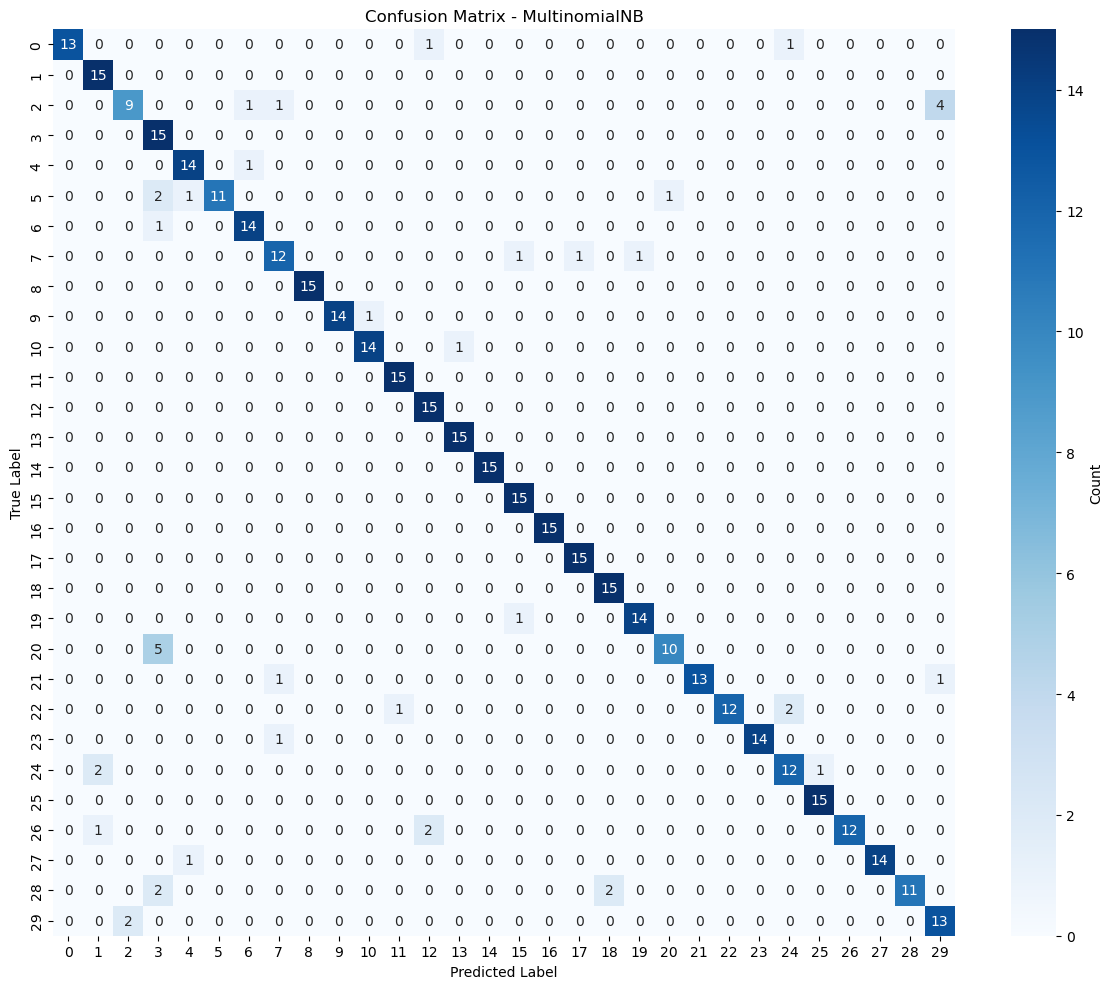

In [33]:
# A.1_1: Naive Bayes - No Preprocessing
print("\n--- A.1: Naive Bayes | No Preprocessing | (1,2)gram ---")
X_train_prep_A1_1 = preprocessing(X_train, remove_stopwords=False, use_lemmatizer=False)
X_test_prep_A1_1 = preprocessing(X_test, remove_stopwords=False, use_lemmatizer=False)
vectorizer_A1_1, X_train_vec_A1, X_test_vec_A1 = vectorize_texts_1_2gram(X_train_prep_A1_1, X_test_prep_A1_1, max_features=5000)
mnb_model_A1_1 = MultinomialNB(alpha=0.1)
train_and_evaluate_model(mnb_model_A1_1, X_train_vec_A1, y_train, X_test_vec_A1, y_test)

#### Stopwords Only


--- A.1.2: Naive Bayes | Stopwords Only | (1,2)gram ---
--- MultinomialNB Results ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.88      0.93      0.90        15
           2       0.83      0.67      0.74        15
           3       0.60      1.00      0.75        15
           4       0.74      0.93      0.82        15
           5       1.00      0.80      0.89        15
           6       0.85      0.73      0.79        15
           7       0.86      0.80      0.83        15
           8       1.00      0.93      0.97        15
           9       0.92      0.73      0.81        15
          10       0.70      0.93      0.80        15
          11       0.83      1.00      0.91        15
          12       0.83      1.00      0.91        15
          13       0.93      0.87      0.90        15
          14       0.94      1.00      0.97        15
          15       0.94      1.00      0.97     

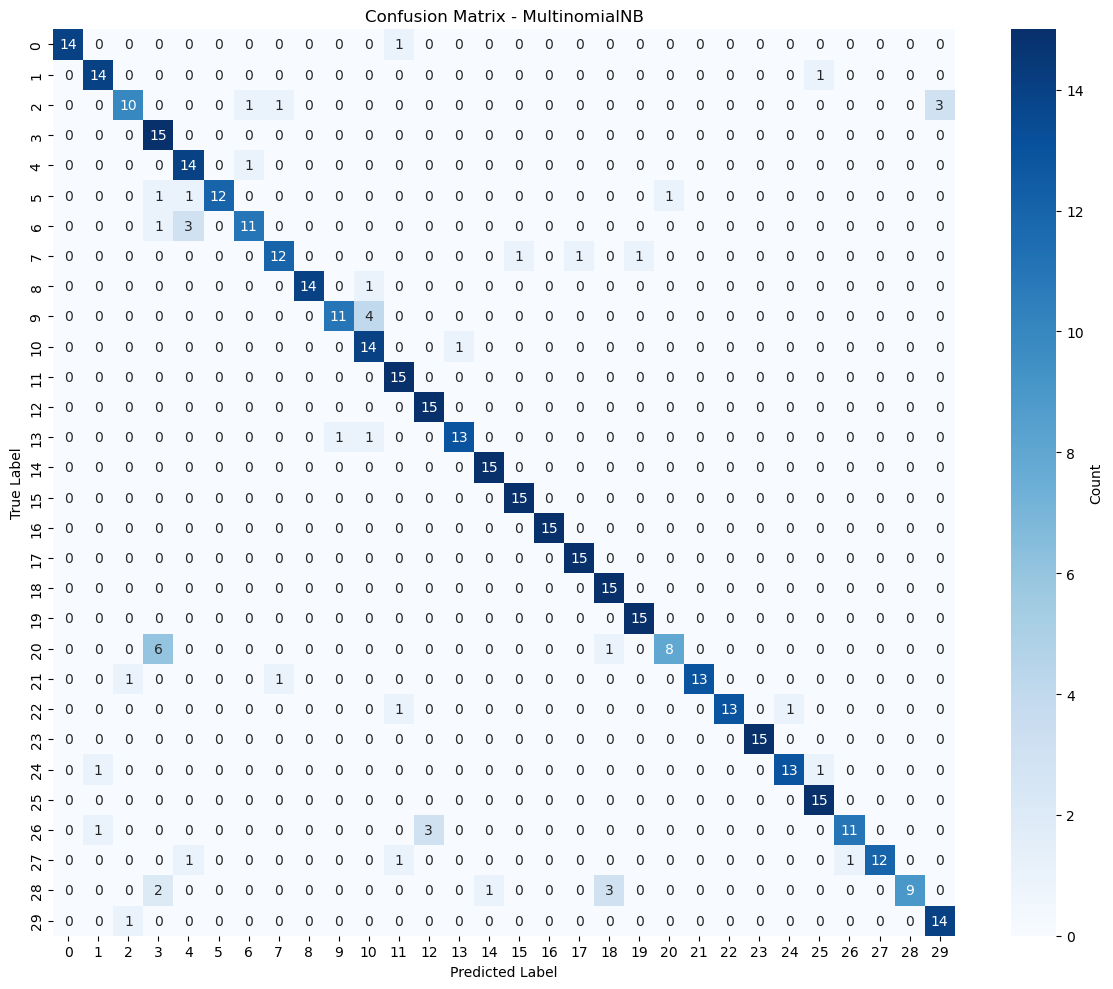

In [34]:

# A.1.2: Naive Bayes - Stopwords Only
print("\n--- A.1.2: Naive Bayes | Stopwords Only | (1,2)gram ---")
X_train_prep_A1_2 = preprocessing(X_train, remove_stopwords=True, use_lemmatizer=False)
X_test_prep_A1_2 = preprocessing(X_test, remove_stopwords=True, use_lemmatizer=False)
vectorizer_1_2, X_train_vec_1_2, X_test_vec_1_2 = vectorize_texts_1_2gram(X_train_prep_A1_2, X_test_prep_A1_2, max_features=5000)
mnb_model_1_2 = MultinomialNB(alpha=0.1)
train_and_evaluate_model(mnb_model_1_2, X_train_vec_1_2, y_train, X_test_vec_1_2, y_test)

#### Lemmatization Only


--- A.1.3: Naive Bayes | Lemmatization Only | (1,2)gram ---
--- MultinomialNB Results ---
              precision    recall  f1-score   support

           0       1.00      0.87      0.93        15
           1       0.88      1.00      0.94        15
           2       0.82      0.60      0.69        15
           3       0.60      1.00      0.75        15
           4       0.83      1.00      0.91        15
           5       1.00      0.73      0.85        15
           6       0.93      0.87      0.90        15
           7       0.86      0.80      0.83        15
           8       1.00      1.00      1.00        15
           9       1.00      0.93      0.97        15
          10       0.88      0.93      0.90        15
          11       0.88      0.93      0.90        15
          12       0.79      1.00      0.88        15
          13       0.93      0.93      0.93        15
          14       1.00      1.00      1.00        15
          15       0.94      1.00      0.97 

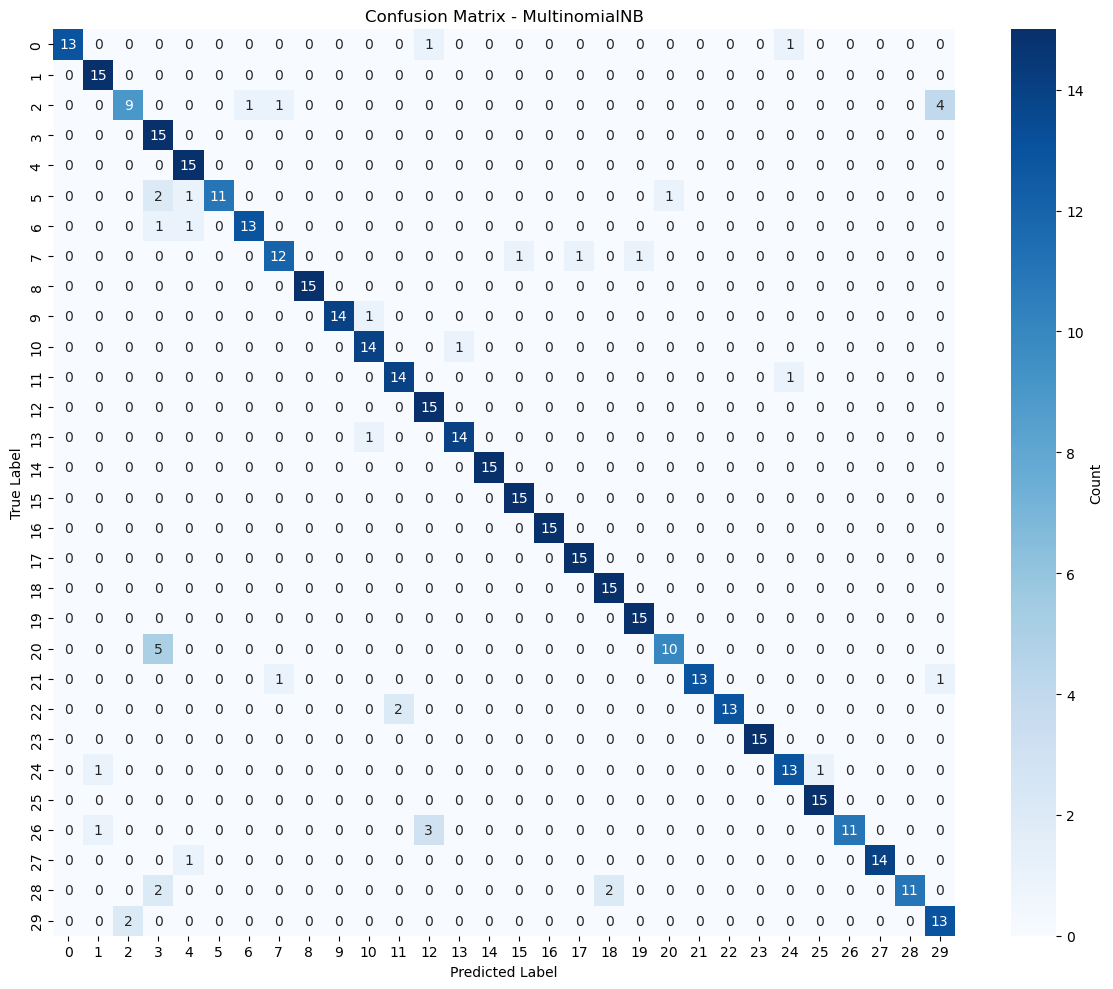

In [35]:

# A.1.3: Naive Bayes - Lemmatization Only
print("\n--- A.1.3: Naive Bayes | Lemmatization Only | (1,2)gram ---")
X_train_prep_A1_3 = preprocessing(X_train, remove_stopwords=False, use_lemmatizer=True)
X_test_prep_A1_3 = preprocessing(X_test, remove_stopwords=False, use_lemmatizer=True)
vectorizer_1_3, X_train_vec_1_3, X_test_vec_1_3 = vectorize_texts_1_2gram(X_train_prep_A1_3, X_test_prep_A1_3, max_features=5000)
mnb_model_1_3 = MultinomialNB(alpha=0.1)
train_and_evaluate_model(mnb_model_1_3, X_train_vec_1_3, y_train, X_test_vec_1_3, y_test)

#### Both


--- A.1.4: Naive Bayes | Stopwords + Lemmatization | (1,2)gram ---
--- MultinomialNB Results ---
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        15
           1       0.88      0.93      0.90        15
           2       0.80      0.53      0.64        15
           3       0.60      1.00      0.75        15
           4       0.78      0.93      0.85        15
           5       1.00      0.80      0.89        15
           6       0.92      0.73      0.81        15
           7       0.75      0.80      0.77        15
           8       1.00      1.00      1.00        15
           9       0.92      0.73      0.81        15
          10       0.74      0.93      0.82        15
          11       0.88      0.93      0.90        15
          12       0.83      1.00      0.91        15
          13       0.93      0.87      0.90        15
          14       0.94      1.00      0.97        15
          15       0.88      1.00    

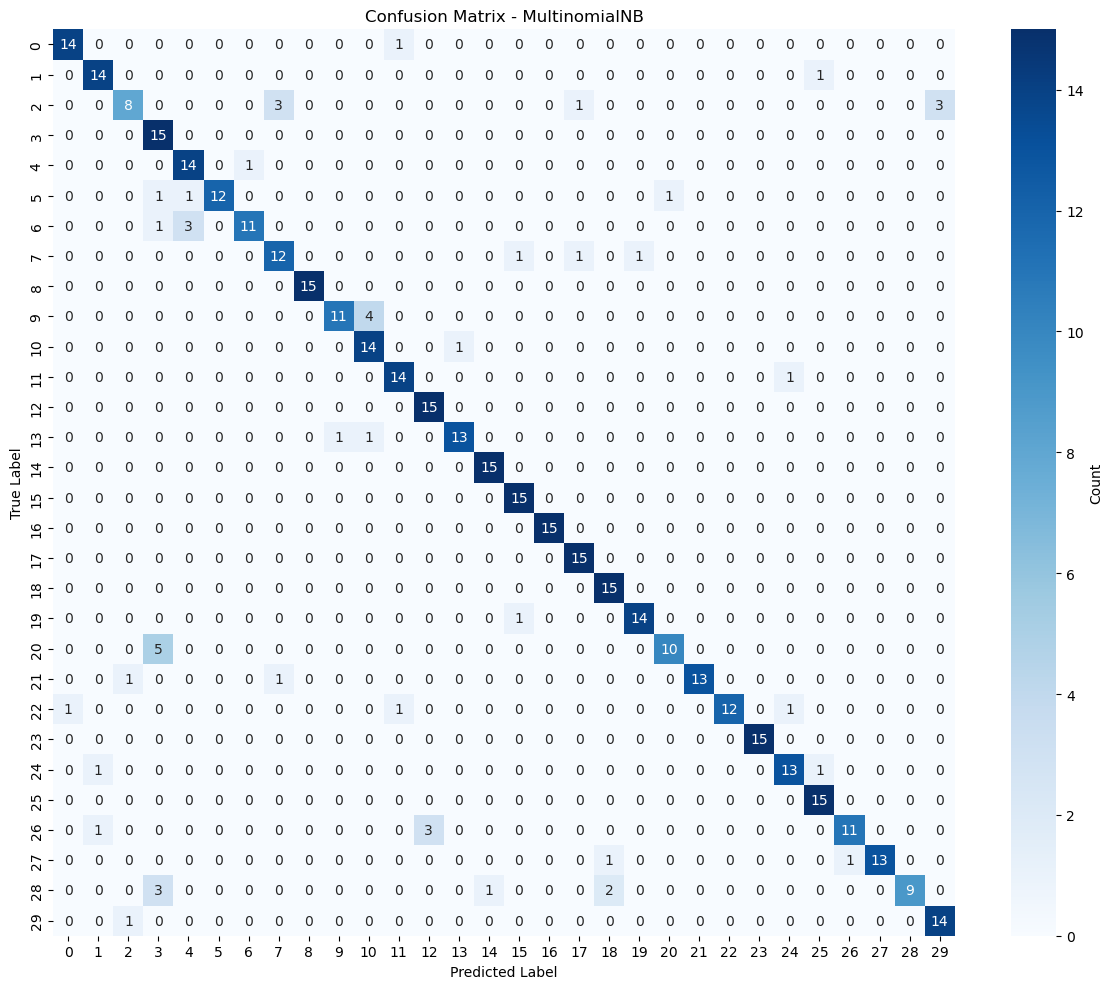

In [36]:

# A.1.4: Naive Bayes - Both
print("\n--- A.1.4: Naive Bayes | Stopwords + Lemmatization | (1,2)gram ---")
X_train_prep_1_4 = preprocessing(X_train, remove_stopwords=True, use_lemmatizer=True)
X_test_prep_1_4 = preprocessing(X_test, remove_stopwords=True, use_lemmatizer=True)
vectorizer_1_4, X_train_vec_1_4, X_test_vec_1_4 = vectorize_texts_1_2gram(X_train_prep_1_4, X_test_prep_1_4, max_features=5000)
mnb_model_1_4 = MultinomialNB(alpha=0.1)
train_and_evaluate_model(mnb_model_1_4, X_train_vec_1_4, y_train, X_test_vec_1_4, y_test)


### SVM

#### No Preprocessing


--- A.2.1: SVM | No Preprocessing | (1,2)gram ---
--- SVC Results ---
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        15
           1       1.00      0.93      0.97        15
           2       0.69      0.73      0.71        15
           3       0.88      0.93      0.90        15
           4       0.93      0.93      0.93        15
           5       1.00      0.87      0.93        15
           6       0.93      0.93      0.93        15
           7       0.82      0.93      0.88        15
           8       1.00      1.00      1.00        15
           9       0.92      0.80      0.86        15
          10       0.87      0.87      0.87        15
          11       1.00      0.93      0.97        15
          12       0.94      1.00      0.97        15
          13       0.94      1.00      0.97        15
          14       1.00      1.00      1.00        15
          15       1.00      1.00      1.00        15
          

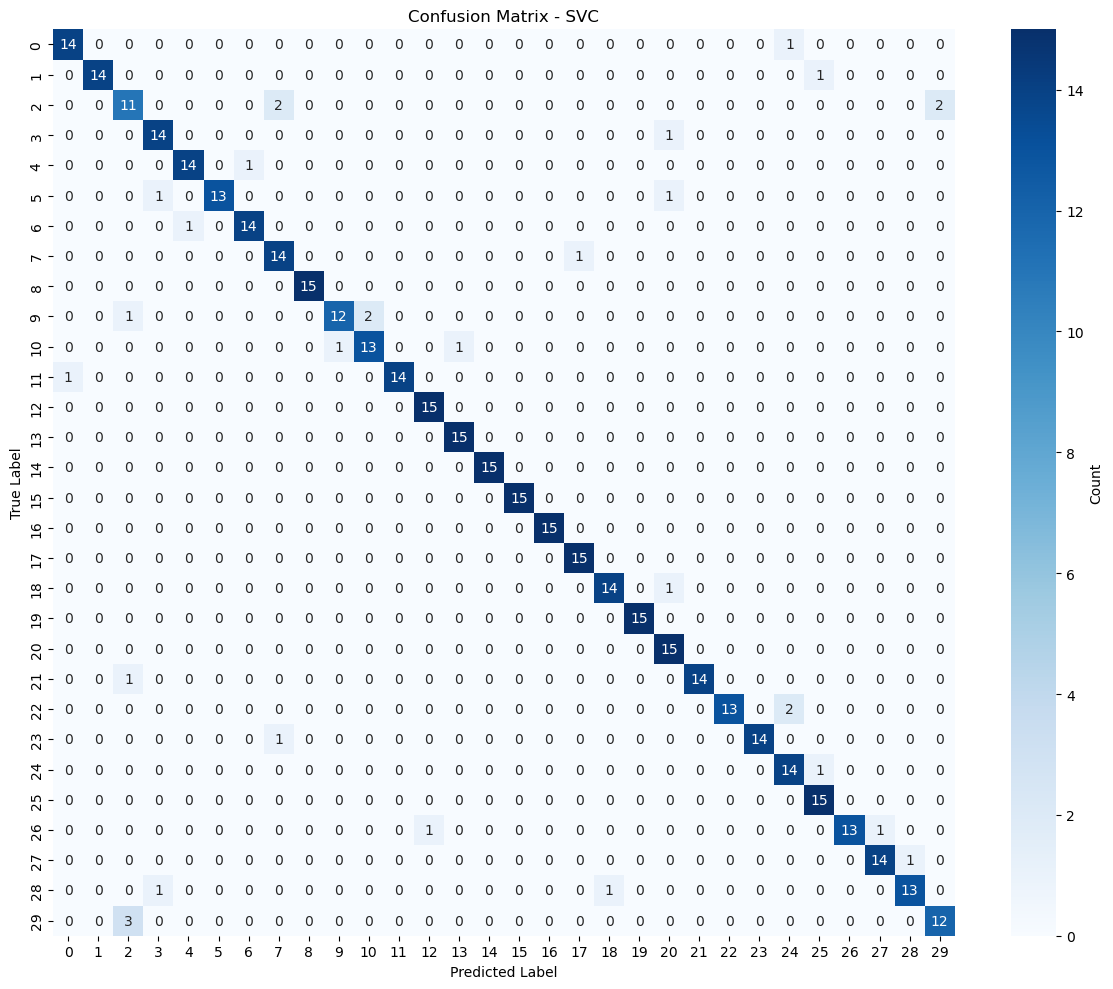

In [37]:
# A.2.1: SVM - No Preprocessing
print("\n--- A.2.1: SVM | No Preprocessing | (1,2)gram ---")
X_train_prep_2_1 = preprocessing(X_train, remove_stopwords=False, use_lemmatizer=False)
X_test_prep_2_1 = preprocessing(X_test, remove_stopwords=False, use_lemmatizer=False)
vectorizer_2_1, X_train_vec_2_1, X_test_vec_2_1 = vectorize_texts_1_2gram(X_train_prep_2_1, X_test_prep_2_1, max_features=5000)
svm_model_2_1 = SVC(kernel='linear', C=1.0, random_state=42)
train_and_evaluate_model(svm_model_2_1, X_train_vec_2_1, y_train, X_test_vec_2_1, y_test)

#### Stopwords Only


--- A.2.2: SVM | Stopwords Only | (1,2)gram ---
--- SVC Results ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       1.00      0.93      0.97        15
           2       0.73      0.73      0.73        15
           3       0.82      0.93      0.88        15
           4       0.88      0.93      0.90        15
           5       1.00      0.87      0.93        15
           6       0.92      0.80      0.86        15
           7       0.87      0.87      0.87        15
           8       1.00      1.00      1.00        15
           9       0.93      0.87      0.90        15
          10       0.93      0.87      0.90        15
          11       1.00      1.00      1.00        15
          12       1.00      1.00      1.00        15
          13       0.94      1.00      0.97        15
          14       1.00      1.00      1.00        15
          15       1.00      1.00      1.00        15
          16

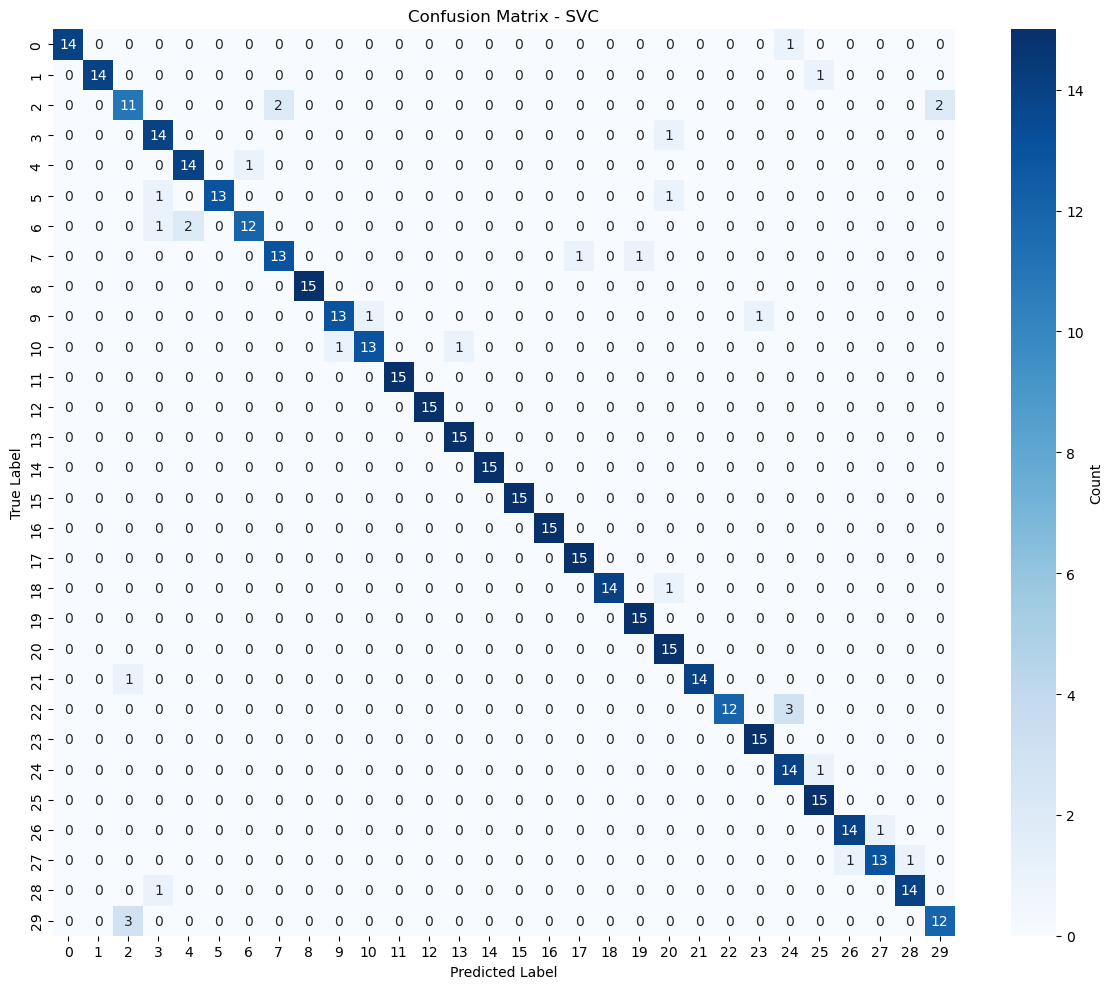

In [38]:

# A.2.2: SVM - Stopwords Only
print("\n--- A.2.2: SVM | Stopwords Only | (1,2)gram ---")
X_train_prep_2_2 = preprocessing(X_train, remove_stopwords=True, use_lemmatizer=False)
X_test_prep_2_2 = preprocessing(X_test, remove_stopwords=True, use_lemmatizer=False)
vectorizer_2_2, X_train_vec_2_2, X_test_vec_2_2 = vectorize_texts_1_2gram(X_train_prep_2_2, X_test_prep_2_2, max_features=5000)
svm_model_2_2 = SVC(kernel='linear', C=1.0, random_state=42)
train_and_evaluate_model(svm_model_2_2, X_train_vec_2_2, y_train, X_test_vec_2_2, y_test)

#### Lemmatization Only


--- A.2.3: SVM | Lemmatization Only | (1,2)gram ---
--- SVC Results ---
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        15
           1       1.00      0.93      0.97        15
           2       0.69      0.73      0.71        15
           3       0.88      1.00      0.94        15
           4       0.93      0.93      0.93        15
           5       1.00      0.87      0.93        15
           6       0.87      0.87      0.87        15
           7       0.88      0.93      0.90        15
           8       1.00      1.00      1.00        15
           9       0.93      0.93      0.93        15
          10       1.00      0.87      0.93        15
          11       1.00      0.93      0.97        15
          12       0.94      1.00      0.97        15
          13       0.94      1.00      0.97        15
          14       1.00      1.00      1.00        15
          15       1.00      1.00      1.00        15
        

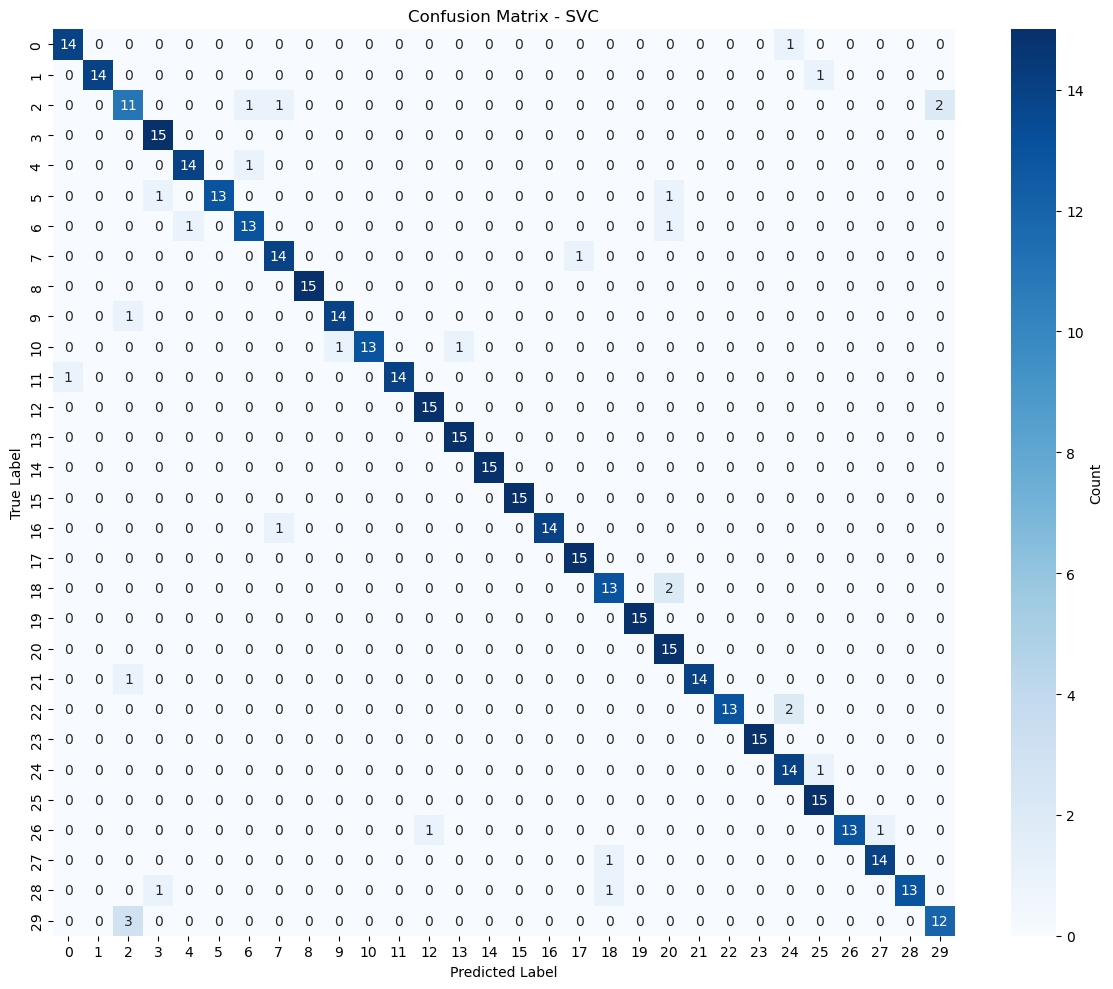

In [39]:

# A.2.3: SVM - Lemmatization Only
print("\n--- A.2.3: SVM | Lemmatization Only | (1,2)gram ---")
X_train_prep_2_3 = preprocessing(X_train, remove_stopwords=False, use_lemmatizer=True)
X_test_prep_2_3 = preprocessing(X_test, remove_stopwords=False, use_lemmatizer=True)
vectorizer_2_3, X_train_vec_2_3, X_test_vec_2_3 = vectorize_texts_1_2gram(X_train_prep_2_3, X_test_prep_2_3, max_features=5000)
svm_model_2_3 = SVC(kernel='linear', C=1.0, random_state=42)
train_and_evaluate_model(svm_model_2_3, X_train_vec_2_3, y_train, X_test_vec_2_3, y_test)

#### Both


--- A.2.4: SVM | Stopwords + Lemmatization | (1,2)gram ---
--- SVC Results ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       1.00      0.93      0.97        15
           2       0.79      0.73      0.76        15
           3       0.93      0.93      0.93        15
           4       0.82      0.93      0.88        15
           5       1.00      0.87      0.93        15
           6       0.93      0.87      0.90        15
           7       0.81      0.87      0.84        15
           8       1.00      1.00      1.00        15
           9       0.93      0.87      0.90        15
          10       0.87      0.87      0.87        15
          11       1.00      0.93      0.97        15
          12       0.94      1.00      0.97        15
          13       0.93      0.93      0.93        15
          14       1.00      1.00      1.00        15
          15       1.00      1.00      1.00        15
 

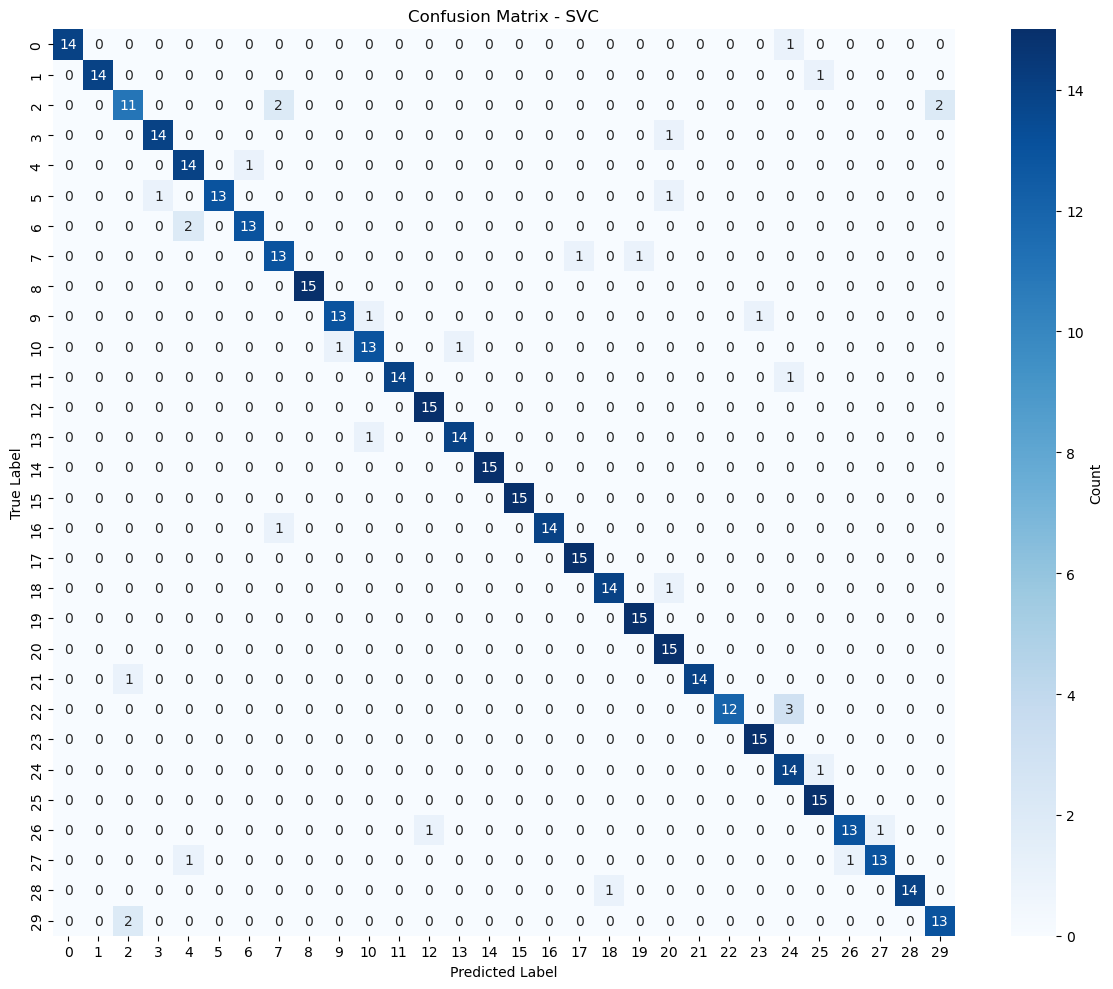

In [40]:

# A.2.4: SVM - Both
print("\n--- A.2.4: SVM | Stopwords + Lemmatization | (1,2)gram ---")
X_train_prep_2_4 = preprocessing(X_train, remove_stopwords=True, use_lemmatizer=True)
X_test_prep_2_4 = preprocessing(X_test, remove_stopwords=True, use_lemmatizer=True)
vectorizer_2_4, X_train_vec_2_4, X_test_vec_2_4 = vectorize_texts_1_2gram(X_train_prep_2_4, X_test_prep_2_4, max_features=5000)
svm_model_2_4 = SVC(kernel='linear', C=1.0, random_state=42)
train_and_evaluate_model(svm_model_2_4, X_train_vec_2_4, y_train, X_test_vec_2_4, y_test)

### Logistic Regression

#### No Preprocessing


--- A.3.1: Logistic Regression | No Preprocessing | (1,2)gram ---


c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- LogisticRegression Results ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.88      0.93      0.90        15
           2       0.80      0.80      0.80        15
           3       0.79      1.00      0.88        15
           4       0.78      0.93      0.85        15
           5       1.00      0.80      0.89        15
           6       0.86      0.80      0.83        15
           7       0.86      0.80      0.83        15
           8       1.00      1.00      1.00        15
           9       0.88      1.00      0.94        15
          10       0.93      0.87      0.90        15
          11       0.94      1.00      0.97        15
          12       0.88      1.00      0.94        15
          13       0.93      0.87      0.90        15
          14       1.00      1.00      1.00        15
          15       0.88      1.00      0.94        15
          16       1.00      1.00      1.00   

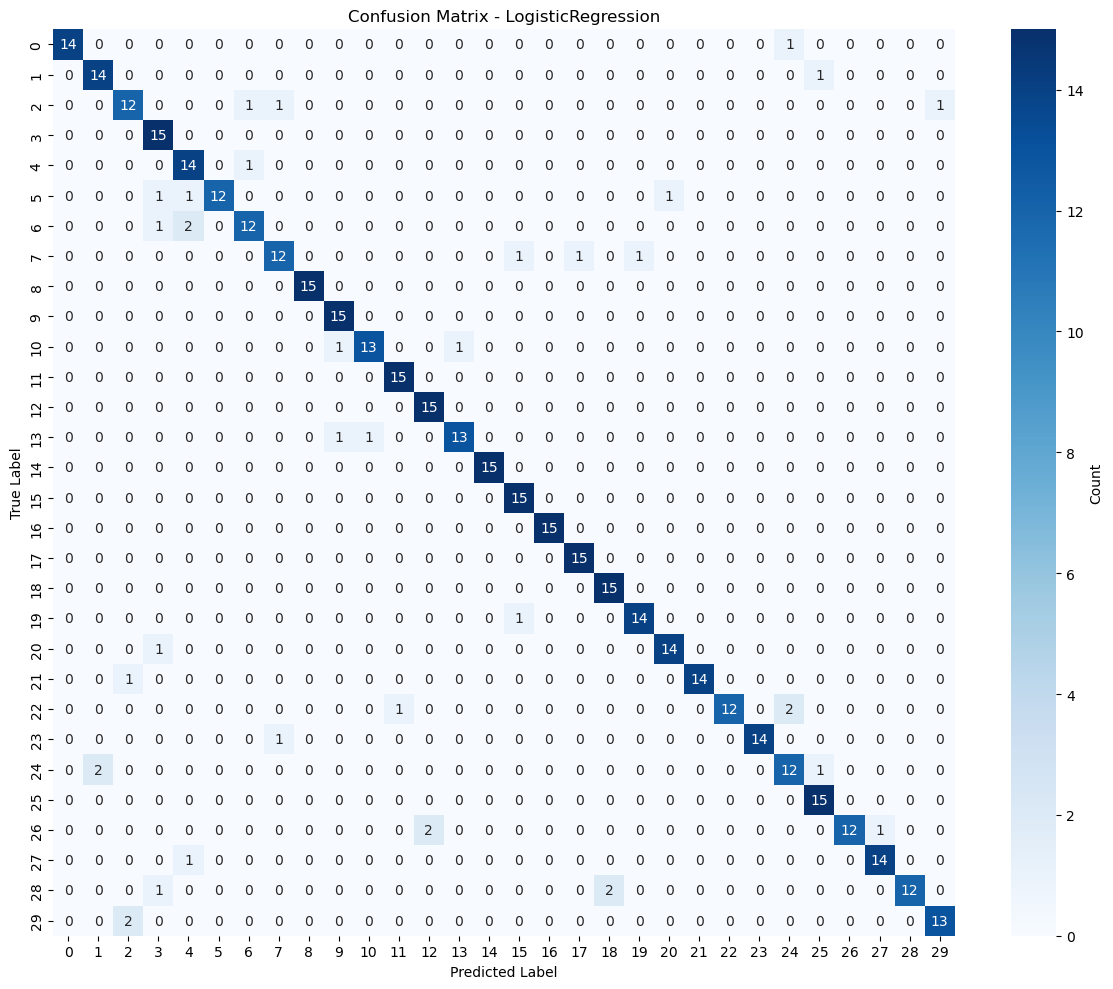

In [41]:

# A.3.1: Logistic Regression - No Preprocessing
print("\n--- A.3.1: Logistic Regression | No Preprocessing | (1,2)gram ---")
X_train_prep_3_1 = preprocessing(X_train, remove_stopwords=False, use_lemmatizer=False)
X_test_prep_3_1 = preprocessing(X_test, remove_stopwords=False, use_lemmatizer=False)
vectorizer_3_1, X_train_vec_3_1, X_test_vec_3_1 = vectorize_texts_1_2gram(X_train_prep_3_1, X_test_prep_3_1, max_features=5000)
lr_model_3_1 = LogisticRegression(max_iter=2000, C=2.0, random_state=42, solver='saga', multi_class='multinomial')
train_and_evaluate_model(lr_model_3_1, X_train_vec_3_1, y_train, X_test_vec_3_1, y_test)

#### Stopwords Only 


--- A.3.2: Logistic Regression | Stopwords Only | (1,2)gram ---


c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- LogisticRegression Results ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.93      0.93      0.93        15
           2       0.85      0.73      0.79        15
           3       0.78      0.93      0.85        15
           4       0.74      0.93      0.82        15
           5       1.00      0.80      0.89        15
           6       0.91      0.67      0.77        15
           7       0.86      0.80      0.83        15
           8       1.00      1.00      1.00        15
           9       0.88      0.93      0.90        15
          10       0.87      0.87      0.87        15
          11       1.00      1.00      1.00        15
          12       0.88      1.00      0.94        15
          13       0.93      0.87      0.90        15
          14       1.00      1.00      1.00        15
          15       0.88      1.00      0.94        15
          16       1.00      1.00      1.00   

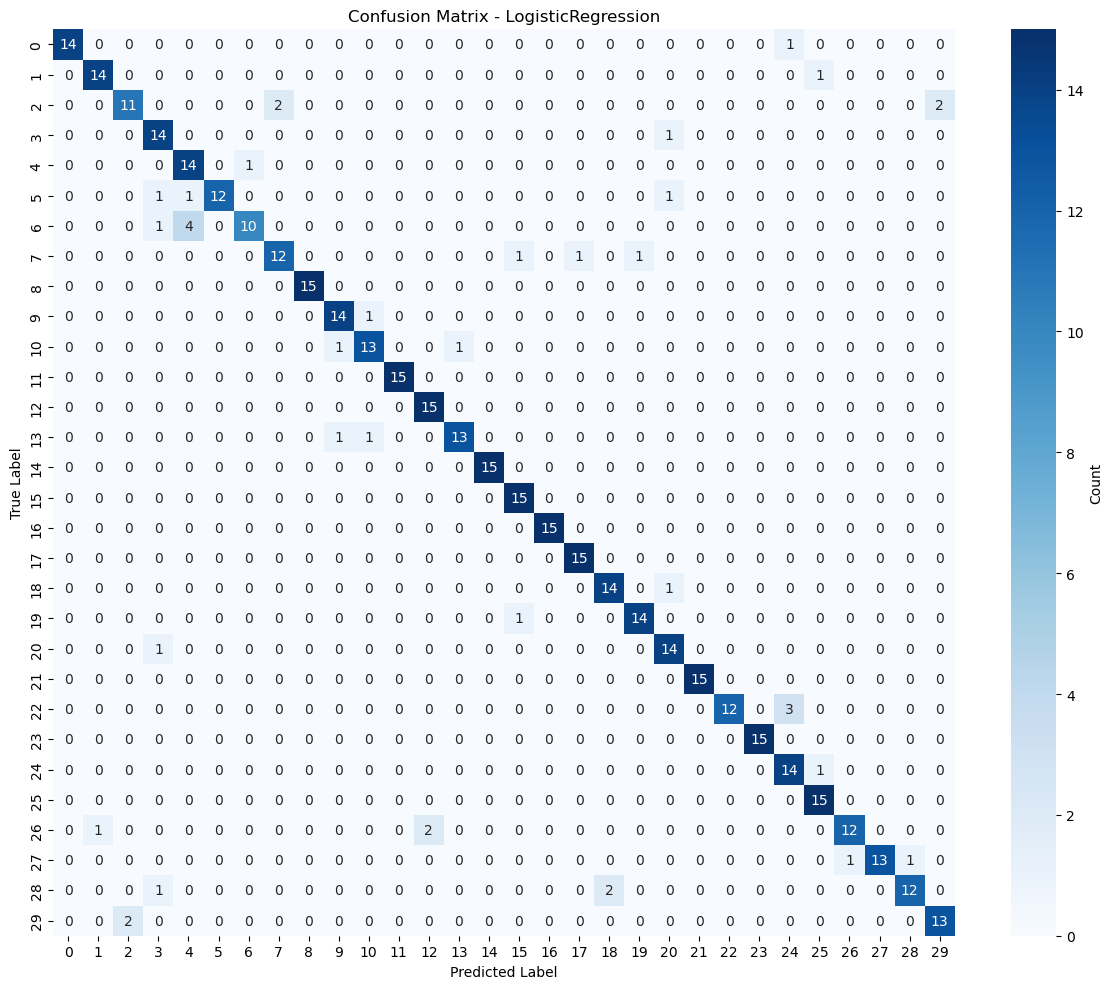

In [42]:

# A.3.2: Logistic Regression - Stopwords Only
print("\n--- A.3.2: Logistic Regression | Stopwords Only | (1,2)gram ---")
X_train_prep_3_2 = preprocessing(X_train, remove_stopwords=True, use_lemmatizer=False)
X_test_prep_3_2 = preprocessing(X_test, remove_stopwords=True, use_lemmatizer=False)
vectorizer_3_2, X_train_vec_3_2, X_test_vec_3_2 = vectorize_texts_1_2gram(X_train_prep_3_2, X_test_prep_3_2, max_features=5000)
lr_model_3_2 = LogisticRegression(max_iter=2000, C=2.0, random_state=42, solver='saga', multi_class='multinomial')
train_and_evaluate_model(lr_model_3_2, X_train_vec_3_2, y_train, X_test_vec_3_2, y_test)

#### Lemmatization Only


--- A.3.3: Logistic Regression | Lemmatization Only | (1,2)gram ---


c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- LogisticRegression Results ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.93      0.93      0.93        15
           2       0.79      0.73      0.76        15
           3       0.83      1.00      0.91        15
           4       0.74      0.93      0.82        15
           5       1.00      0.80      0.89        15
           6       0.92      0.73      0.81        15
           7       0.86      0.80      0.83        15
           8       1.00      1.00      1.00        15
           9       0.88      1.00      0.94        15
          10       0.93      0.87      0.90        15
          11       0.88      0.93      0.90        15
          12       0.88      1.00      0.94        15
          13       0.93      0.87      0.90        15
          14       1.00      1.00      1.00        15
          15       0.88      1.00      0.94        15
          16       1.00      1.00      1.00   

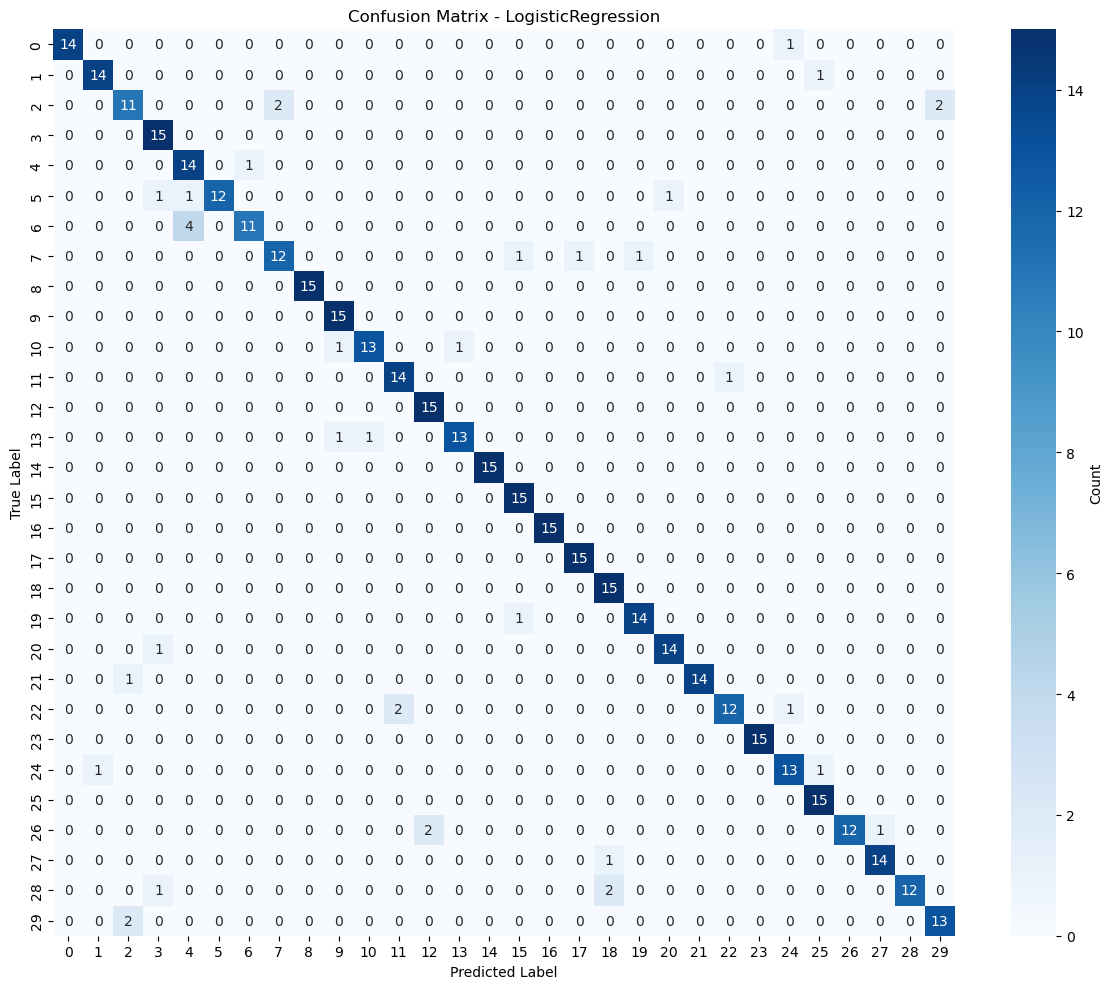

In [43]:

# A.3.3: Logistic Regression - Lemmatization Only
print("\n--- A.3.3: Logistic Regression | Lemmatization Only | (1,2)gram ---")
X_train_prep_3_3 = preprocessing(X_train, remove_stopwords=False, use_lemmatizer=True)
X_test_prep_3_3 = preprocessing(X_test, remove_stopwords=False, use_lemmatizer=True)
vectorizer_3_3, X_train_vec_3_3, X_test_vec_3_3 = vectorize_texts_1_2gram(X_train_prep_3_3, X_test_prep_3_3, max_features=5000)
lr_model_3_3 = LogisticRegression(max_iter=2000, C=2.0, random_state=42, solver='saga', multi_class='multinomial')
train_and_evaluate_model(lr_model_3_3, X_train_vec_3_3, y_train, X_test_vec_3_3, y_test)

#### Both


--- A.3.4: Logistic Regression | Stopwords + Lemmatization | (1,2)gram ---


c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- LogisticRegression Results ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.93      0.93      0.93        15
           2       0.85      0.73      0.79        15
           3       0.82      0.93      0.88        15
           4       0.74      0.93      0.82        15
           5       1.00      0.80      0.89        15
           6       0.91      0.67      0.77        15
           7       0.86      0.80      0.83        15
           8       1.00      1.00      1.00        15
           9       0.88      0.93      0.90        15
          10       0.86      0.80      0.83        15
          11       1.00      0.93      0.97        15
          12       0.88      1.00      0.94        15
          13       0.87      0.87      0.87        15
          14       0.94      1.00      0.97        15
          15       0.88      1.00      0.94        15
          16       1.00      1.00      1.00   

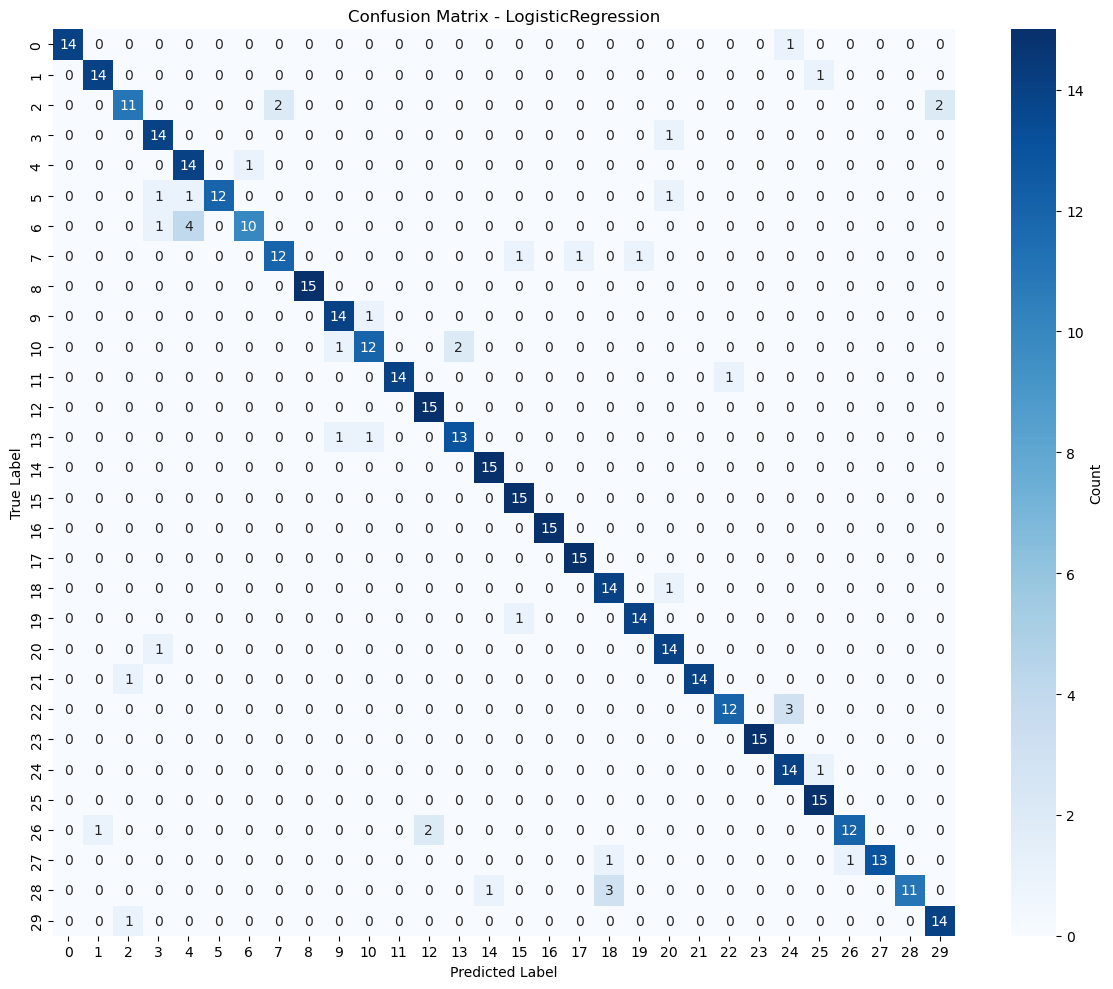

In [44]:

# A.3.4: Logistic Regression - Both
print("\n--- A.3.4: Logistic Regression | Stopwords + Lemmatization | (1,2)gram ---")
X_train_prep_3_4 = preprocessing(X_train, remove_stopwords=True, use_lemmatizer=True)
X_test_prep_3_4 = preprocessing(X_test, remove_stopwords=True, use_lemmatizer=True)
vectorizer_3_4, X_train_vec_3_4, X_test_vec_3_4 = vectorize_texts_1_2gram(X_train_prep_3_4, X_test_prep_3_4, max_features=5000)
lr_model_3_4 = LogisticRegression(max_iter=2000, C=2.0, random_state=42, solver='saga', multi_class='multinomial')
train_and_evaluate_model(lr_model_3_4, X_train_vec_3_4, y_train, X_test_vec_3_4, y_test)

## N-gram Effect

In [45]:
# Preprocessing (constant)
X_train_prep_B = preprocessing(X_train, remove_stopwords=True, use_lemmatizer=True)
X_test_prep_B = preprocessing(X_test, remove_stopwords=True, use_lemmatizer=True)

### Naive Bayes

#### Unigram


--- B.1.1: Naive Bayes | Stopwords+Lemma | Unigram (1,1) ---
--- MultinomialNB Results ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.94      1.00      0.97        15
           2       0.90      0.60      0.72        15
           3       0.56      1.00      0.71        15
           4       0.82      0.93      0.88        15
           5       1.00      0.73      0.85        15
           6       0.86      0.80      0.83        15
           7       0.80      0.80      0.80        15
           8       1.00      1.00      1.00        15
           9       0.92      0.80      0.86        15
          10       0.82      0.93      0.88        15
          11       0.88      1.00      0.94        15
          12       0.83      1.00      0.91        15
          13       0.87      0.87      0.87        15
          14       0.94      1.00      0.97        15
          15       0.94      1.00      0.97

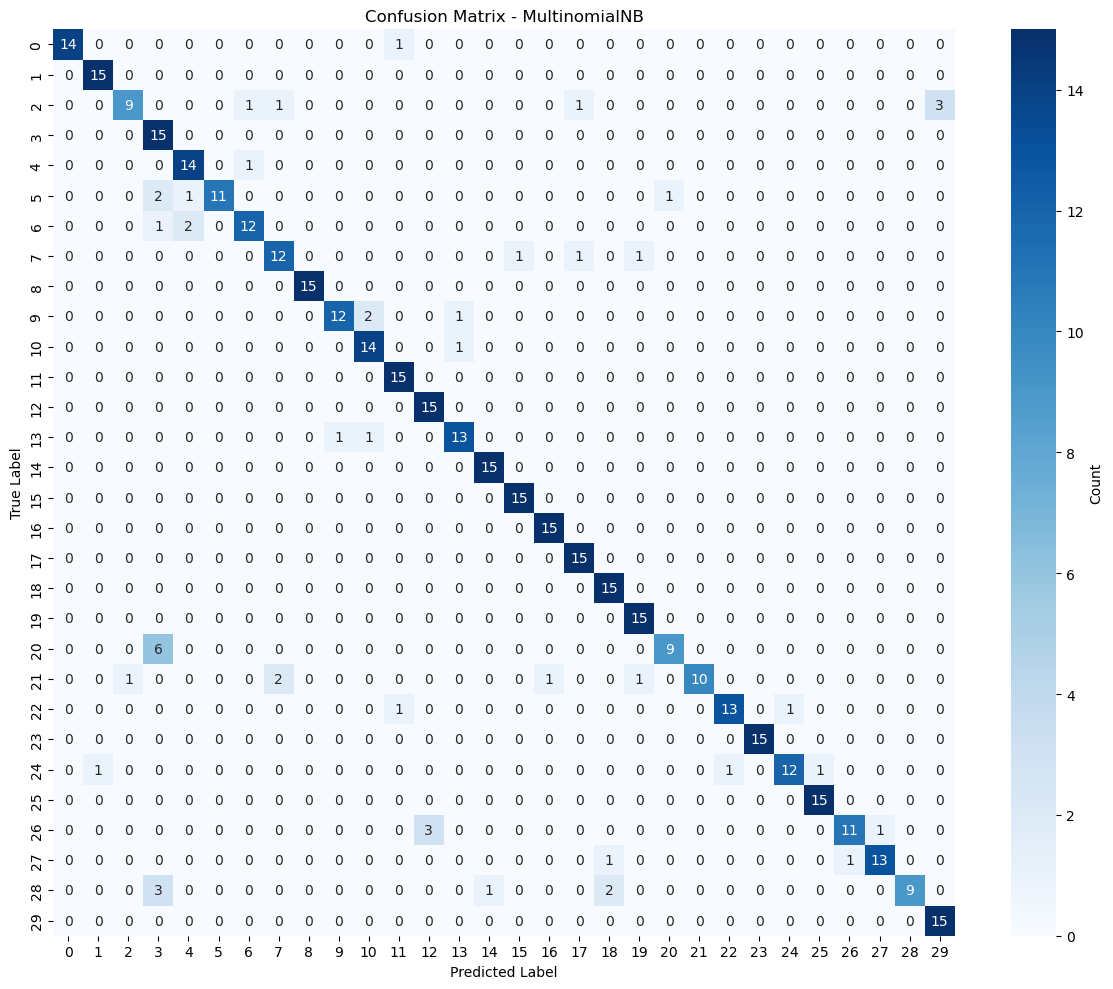

In [46]:
# B.1.1: Naive Bayes - Unigram (1,1)
print("\n--- B.1.1: Naive Bayes | Stopwords+Lemma | Unigram (1,1) ---")
vectorizer_B1_1, X_train_vec_B1_1, X_test_vec_B1_1 = vectorize_texts_1gram(X_train_prep_B, X_test_prep_B, max_features=5000)
mnb_model_B1 = MultinomialNB(alpha=0.1)
train_and_evaluate_model(mnb_model_B1, X_train_vec_B1_1, y_train, X_test_vec_B1_1, y_test)


#### Bigram


--- B.1.2: Naive Bayes | Stopwords+Lemma | Bigram (2,2) ---
--- MultinomialNB Results ---
              precision    recall  f1-score   support

           0       0.67      0.40      0.50        15
           1       0.58      0.93      0.72        15
           2       0.70      0.47      0.56        15
           3       0.57      0.80      0.67        15
           4       0.75      1.00      0.86        15
           5       1.00      0.53      0.70        15
           6       0.91      0.67      0.77        15
           7       0.50      0.60      0.55        15
           8       0.81      0.87      0.84        15
           9       0.77      0.67      0.71        15
          10       0.67      0.93      0.78        15
          11       0.64      0.93      0.76        15
          12       0.52      1.00      0.68        15
          13       0.56      0.33      0.42        15
          14       0.88      1.00      0.94        15
          15       0.88      1.00      0.94 

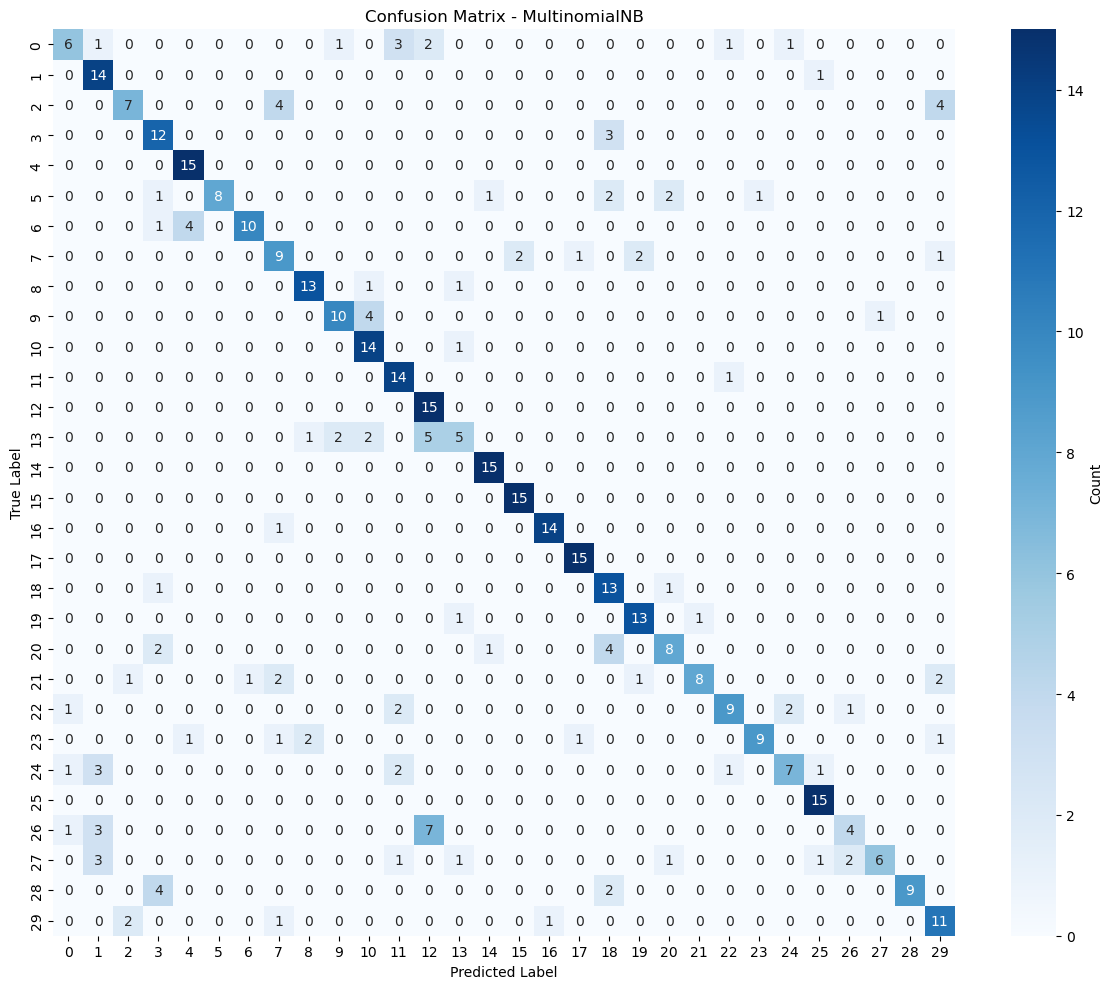

In [47]:
# B.1.2: Naive Bayes - Bigram (2,2)
print("\n--- B.1.2: Naive Bayes | Stopwords+Lemma | Bigram (2,2) ---")
vectorizer_1_2, X_train_vec_1_2, X_test_vec_1_2 = vectorize_texts_2gram(X_train_prep_B, X_test_prep_B, max_features=5000)
mnb_model_1_2 = MultinomialNB(alpha=0.1)
train_and_evaluate_model(mnb_model_1_2, X_train_vec_1_2, y_train, X_test_vec_1_2, y_test)

#### Unigram + Bigram


--- B.1.3: Naive Bayes | Stopwords+Lemma | Unigram+Bigram (1,2) ---
--- MultinomialNB Results ---
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        15
           1       0.88      0.93      0.90        15
           2       0.80      0.53      0.64        15
           3       0.60      1.00      0.75        15
           4       0.78      0.93      0.85        15
           5       1.00      0.80      0.89        15
           6       0.92      0.73      0.81        15
           7       0.75      0.80      0.77        15
           8       1.00      1.00      1.00        15
           9       0.92      0.73      0.81        15
          10       0.74      0.93      0.82        15
          11       0.88      0.93      0.90        15
          12       0.83      1.00      0.91        15
          13       0.93      0.87      0.90        15
          14       0.94      1.00      0.97        15
          15       0.88      1.00   

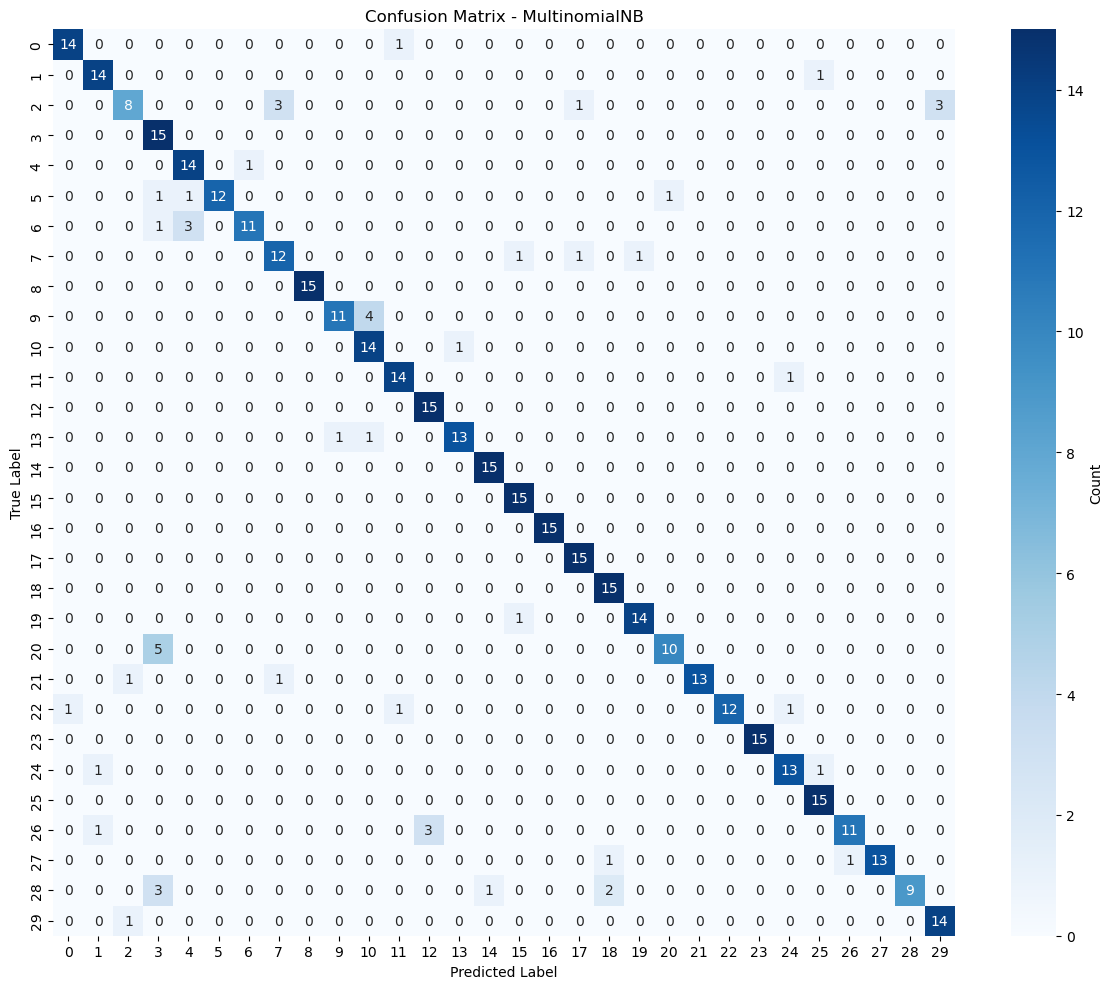

In [48]:
# B.1.3: Naive Bayes - Unigram+Bigram (1,2)
print("\n--- B.1.3: Naive Bayes | Stopwords+Lemma | Unigram+Bigram (1,2) ---")
vectorizer_1_3, X_train_vec_1_3, X_test_vec_1_3 = vectorize_texts_1_2gram(X_train_prep_B, X_test_prep_B, max_features=5000)
mnb_model_1_3 = MultinomialNB(alpha=0.1)
train_and_evaluate_model(mnb_model_1_3, X_train_vec_1_3, y_train, X_test_vec_1_3, y_test)

### SVM

#### Unigram


--- B.2.1: SVM | Stopwords+Lemma | Unigram (1,1) ---
--- SVC Results ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       1.00      0.93      0.97        15
           2       0.69      0.73      0.71        15
           3       1.00      0.93      0.97        15
           4       1.00      0.93      0.97        15
           5       1.00      0.87      0.93        15
           6       0.94      1.00      0.97        15
           7       0.81      0.87      0.84        15
           8       1.00      1.00      1.00        15
           9       0.93      0.93      0.93        15
          10       0.93      0.87      0.90        15
          11       0.93      0.93      0.93        15
          12       0.94      1.00      0.97        15
          13       0.93      0.93      0.93        15
          14       1.00      1.00      1.00        15
          15       0.94      1.00      0.97        15
       

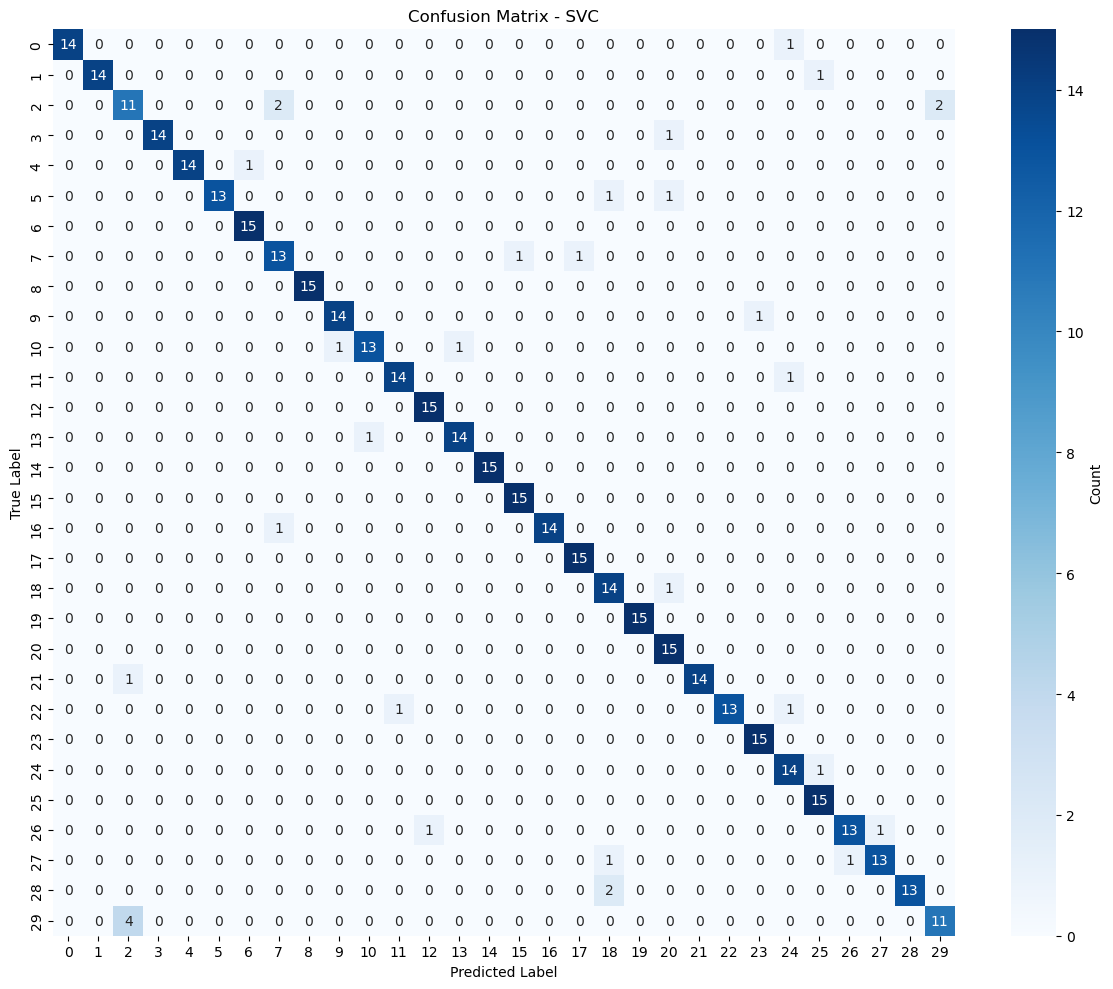

In [49]:
# B.2.1: SVM - Unigram (1,1)
print("\n--- B.2.1: SVM | Stopwords+Lemma | Unigram (1,1) ---")
vectorizer_B2_1, X_train_vec_B2_1, X_test_vec_B2_1 = vectorize_texts_1gram(X_train_prep_B, X_test_prep_B, max_features=5000)
svm_model_B2_1 = SVC(kernel='linear', C=1.0, random_state=42)
train_and_evaluate_model(svm_model_B2_1, X_train_vec_B2_1, y_train, X_test_vec_B2_1, y_test)

#### Bigram


--- B.2.2: SVM | Stopwords+Lemma | Bigram (2,2) ---
--- SVC Results ---
              precision    recall  f1-score   support

           0       0.81      0.87      0.84        15
           1       0.78      0.93      0.85        15
           2       0.71      0.67      0.69        15
           3       0.85      0.73      0.79        15
           4       0.88      0.93      0.90        15
           5       0.65      0.73      0.69        15
           6       0.92      0.80      0.86        15
           7       0.60      0.60      0.60        15
           8       0.93      0.93      0.93        15
           9       0.86      0.80      0.83        15
          10       0.76      0.87      0.81        15
          11       1.00      0.93      0.97        15
          12       1.00      1.00      1.00        15
          13       0.69      0.73      0.71        15
          14       1.00      1.00      1.00        15
          15       0.94      1.00      0.97        15
        

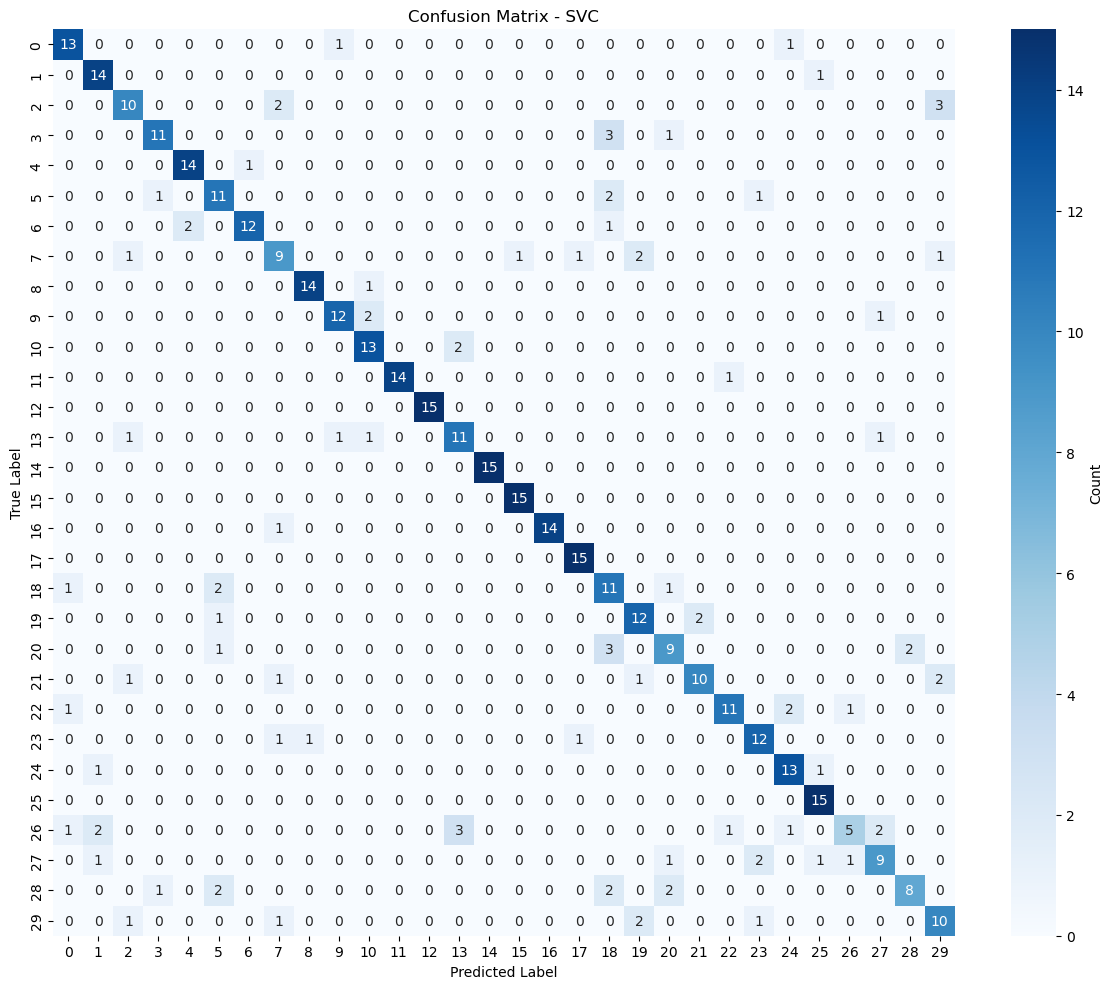

In [50]:
# B.2.2: SVM - Bigram (2,2)
print("\n--- B.2.2: SVM | Stopwords+Lemma | Bigram (2,2) ---")
vectorizer_B2_2, X_train_vec_B2_2, X_test_vec_B2_2 = vectorize_texts_2gram(X_train_prep_B, X_test_prep_B, max_features=5000)
svm_model_B2_2 = SVC(kernel='linear', C=1.0, random_state=42)
train_and_evaluate_model(svm_model_B2_2, X_train_vec_B2_2, y_train, X_test_vec_B2_2, y_test)

#### Unigram + Bigram


--- B.2.3: SVM | Stopwords+Lemma | Unigram+Bigram (1,2) ---
--- SVC Results ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       1.00      0.93      0.97        15
           2       0.79      0.73      0.76        15
           3       0.93      0.93      0.93        15
           4       0.82      0.93      0.88        15
           5       1.00      0.87      0.93        15
           6       0.93      0.87      0.90        15
           7       0.81      0.87      0.84        15
           8       1.00      1.00      1.00        15
           9       0.93      0.87      0.90        15
          10       0.87      0.87      0.87        15
          11       1.00      0.93      0.97        15
          12       0.94      1.00      0.97        15
          13       0.93      0.93      0.93        15
          14       1.00      1.00      1.00        15
          15       1.00      1.00      1.00        15


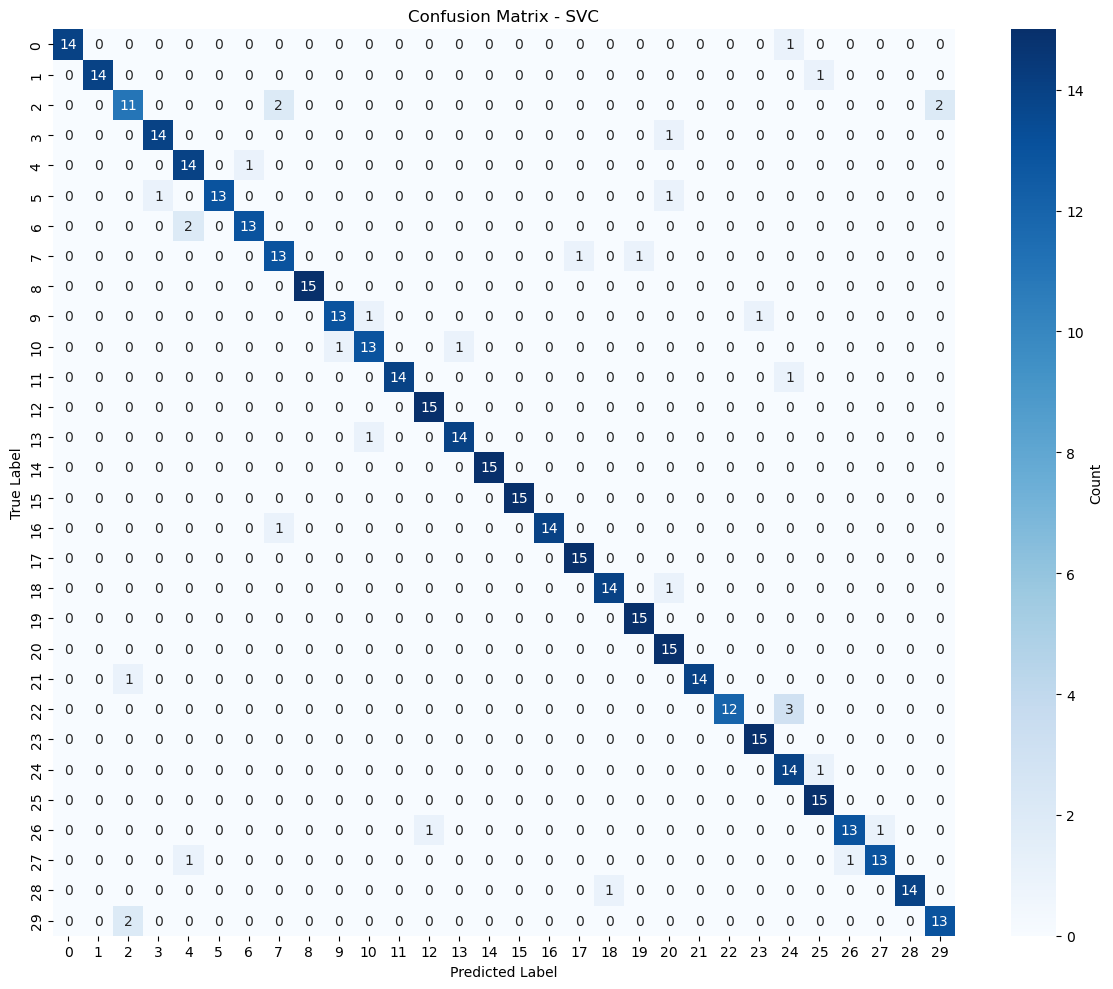

In [51]:
# B.2.3: SVM - Unigram+Bigram (1,2)
print("\n--- B.2.3: SVM | Stopwords+Lemma | Unigram+Bigram (1,2) ---")
vectorizer_B2_3, X_train_vec_B2_3, X_test_vec_B2_3 = vectorize_texts_1_2gram(X_train_prep_B, X_test_prep_B, max_features=5000)
svm_model_B2_3 = SVC(kernel='linear', C=1.0, random_state=42)
train_and_evaluate_model(svm_model_B2_3, X_train_vec_B2_3, y_train, X_test_vec_B2_3, y_test)

### Logistic Regression

#### Unigram


--- B.3.1: Logistic Regression | Stopwords+Lemma | Unigram (1,1) ---


c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- LogisticRegression Results ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.93      0.93      0.93        15
           2       0.91      0.67      0.77        15
           3       0.78      0.93      0.85        15
           4       0.88      0.93      0.90        15
           5       1.00      0.80      0.89        15
           6       0.93      0.87      0.90        15
           7       0.80      0.80      0.80        15
           8       1.00      1.00      1.00        15
           9       0.88      1.00      0.94        15
          10       0.93      0.87      0.90        15
          11       0.93      0.93      0.93        15
          12       0.88      1.00      0.94        15
          13       0.93      0.87      0.90        15
          14       0.94      1.00      0.97        15
          15       0.88      1.00      0.94        15
          16       1.00      1.00      1.00   

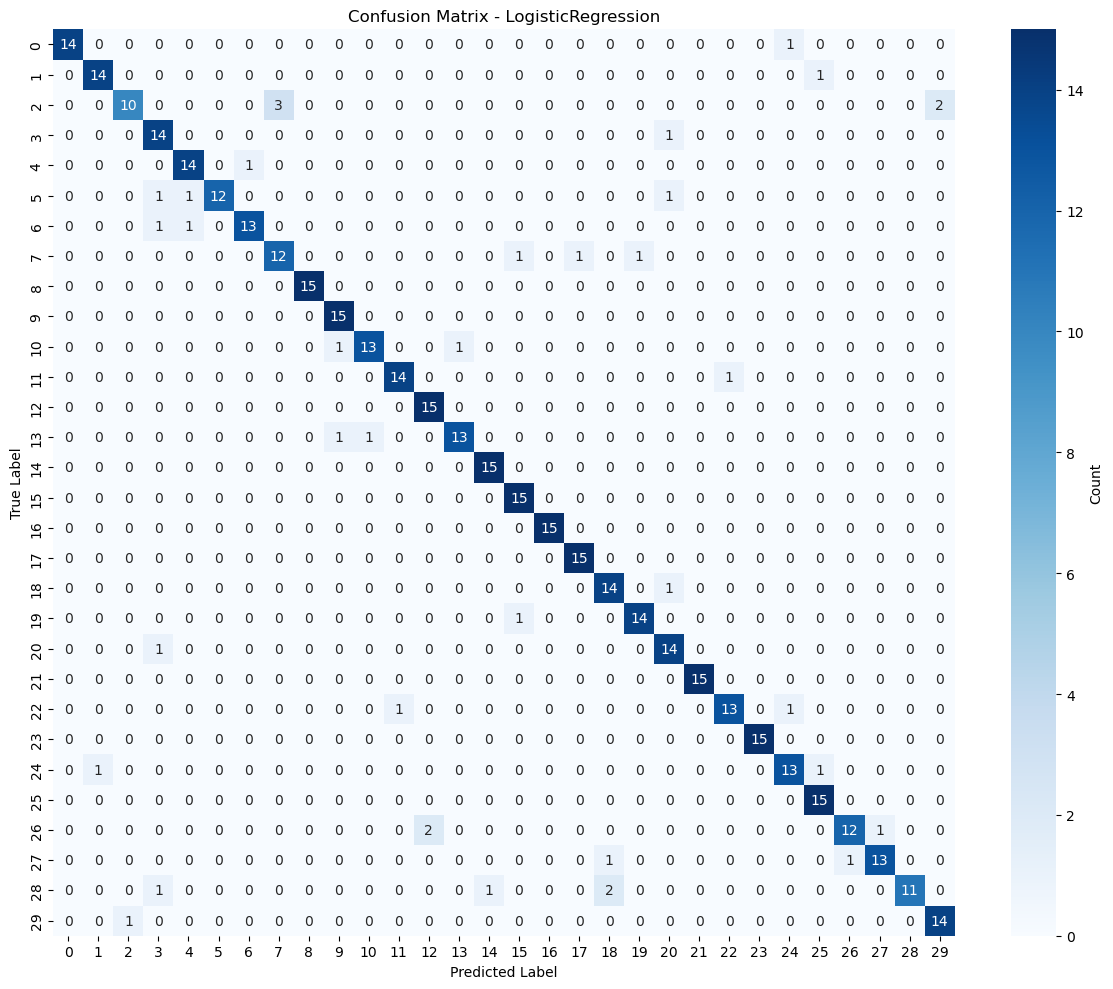

In [52]:
# B.3.1: Logistic Regression - Unigram (1,1)
print("\n--- B.3.1: Logistic Regression | Stopwords+Lemma | Unigram (1,1) ---")
vectorizer_B3_1, X_train_vec_B3_1, X_test_vec_B3_1 = vectorize_texts_1gram(X_train_prep_B, X_test_prep_B, max_features=5000)
lr_model_B3_1 = LogisticRegression(max_iter=2000, C=2.0, random_state=42, solver='saga', multi_class='multinomial')
train_and_evaluate_model(lr_model_B3_1, X_train_vec_B3_1, y_train, X_test_vec_B3_1, y_test)

#### Bigram


--- B.3.2: Logistic Regression | Stopwords+Lemma | Bigram (2,2) ---


c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- LogisticRegression Results ---
              precision    recall  f1-score   support

           0       0.82      0.60      0.69        15
           1       0.70      0.93      0.80        15
           2       0.54      0.47      0.50        15
           3       0.69      0.73      0.71        15
           4       0.78      0.93      0.85        15
           5       0.77      0.67      0.71        15
           6       0.83      0.67      0.74        15
           7       0.57      0.53      0.55        15
           8       0.93      0.93      0.93        15
           9       0.86      0.80      0.83        15
          10       0.68      0.87      0.76        15
          11       0.70      0.93      0.80        15
          12       0.68      1.00      0.81        15
          13       0.60      0.40      0.48        15
          14       1.00      1.00      1.00        15
          15       0.88      1.00      0.94        15
          16       1.00      0.93      0.97   

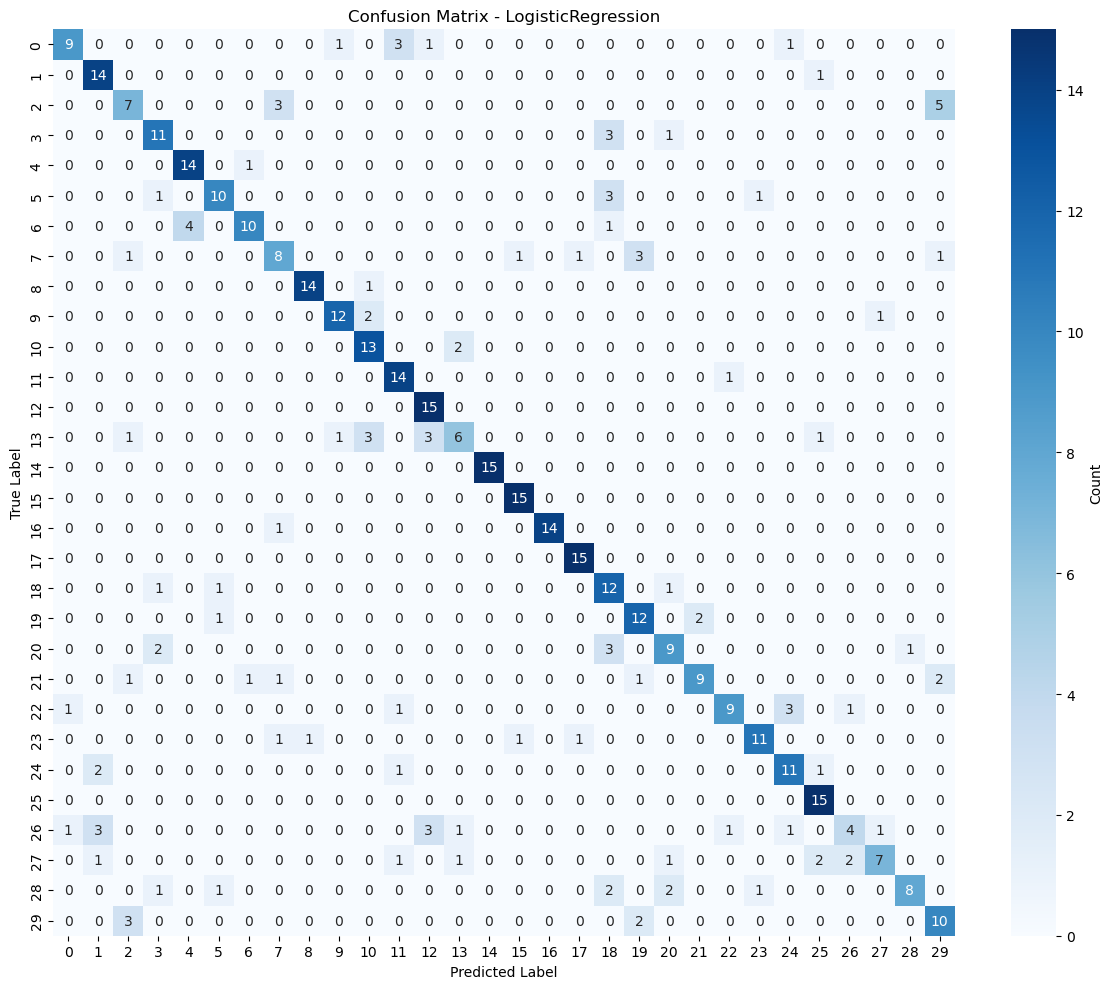

In [53]:
# B.3.2: Logistic Regression - Bigram (2,2)
print("\n--- B.3.2: Logistic Regression | Stopwords+Lemma | Bigram (2,2) ---")
vectorizer_B3_2, X_train_vec_B3_2, X_test_vec_B3_2 = vectorize_texts_2gram(X_train_prep_B, X_test_prep_B, max_features=5000)
lr_model_B3_2 = LogisticRegression(max_iter=2000, C=2.0, random_state=42, solver='saga', multi_class='multinomial')
train_and_evaluate_model(lr_model_B3_2, X_train_vec_B3_2, y_train, X_test_vec_B3_2, y_test)

#### Unigram + Bigram


--- B.3.3: Logistic Regression | Stopwords+Lemma | Unigram+Bigram (1,2) ---


c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- LogisticRegression Results ---
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.93      0.93      0.93        15
           2       0.85      0.73      0.79        15
           3       0.82      0.93      0.88        15
           4       0.74      0.93      0.82        15
           5       1.00      0.80      0.89        15
           6       0.91      0.67      0.77        15
           7       0.86      0.80      0.83        15
           8       1.00      1.00      1.00        15
           9       0.88      0.93      0.90        15
          10       0.86      0.80      0.83        15
          11       1.00      0.93      0.97        15
          12       0.88      1.00      0.94        15
          13       0.87      0.87      0.87        15
          14       0.94      1.00      0.97        15
          15       0.88      1.00      0.94        15
          16       1.00      1.00      1.00   

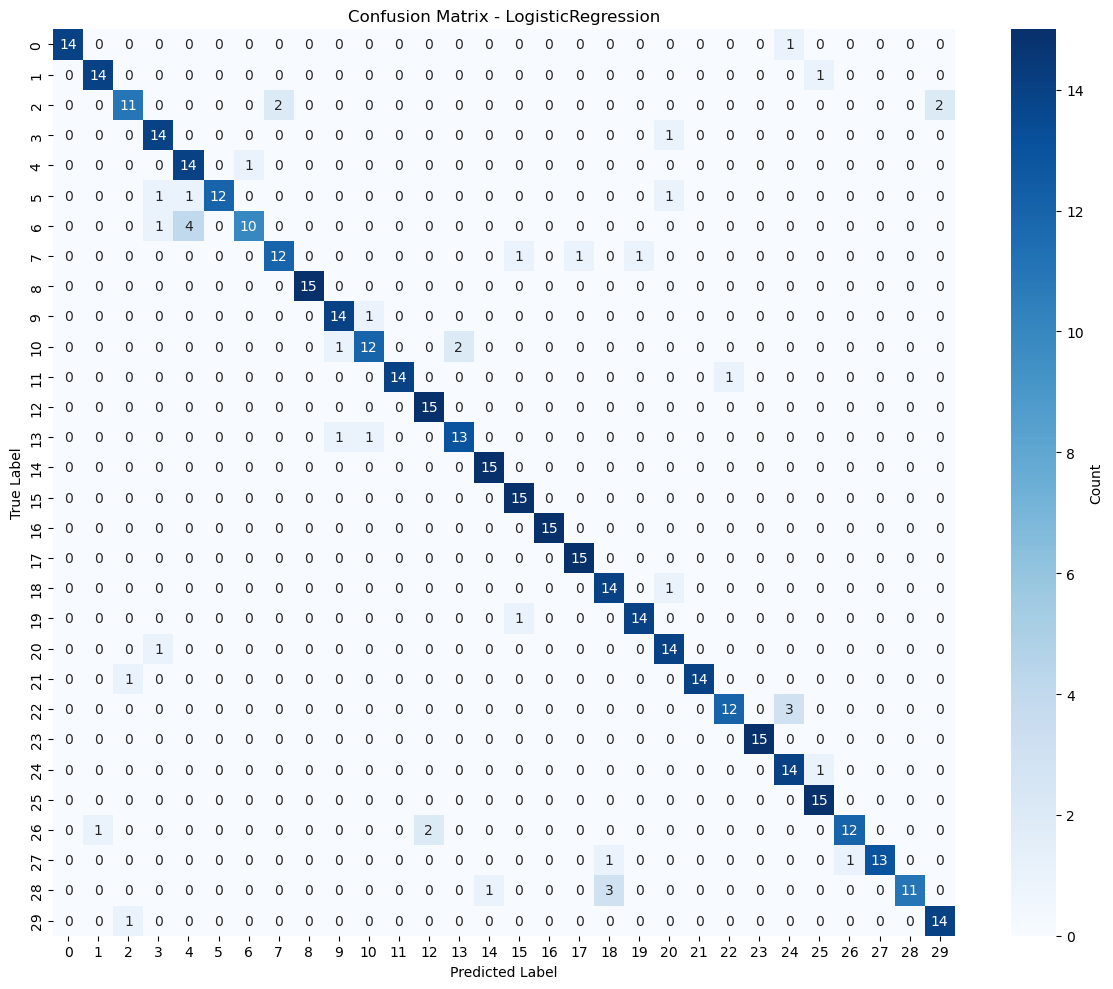

In [54]:
# B.3.3: Logistic Regression - Unigram+Bigram (1,2)
print("\n--- B.3.3: Logistic Regression | Stopwords+Lemma | Unigram+Bigram (1,2) ---")
vectorizer_B3_3, X_train_vec_B3_3, X_test_vec_B3_3 = vectorize_texts_1_2gram(X_train_prep_B, X_test_prep_B, max_features=5000)
lr_model_B3_3 = LogisticRegression(max_iter=2000, C=2.0, random_state=42, solver='saga', multi_class='multinomial')
train_and_evaluate_model(lr_model_B3_3, X_train_vec_B3_3, y_train, X_test_vec_B3_3, y_test)

## Character N-grams

### Naive Bayes

In [55]:
# Preprocessing (constant)
X_train_prep_C = preprocessing(X_train, remove_stopwords=True, use_lemmatizer=True)
X_test_prep_C = preprocessing(X_test, remove_stopwords=True, use_lemmatizer=True)


--- C.1: Naive Bayes | Stopwords+Lemma | Character N-grams (3,5) ---
--- MultinomialNB Results ---
              precision    recall  f1-score   support

           0       0.92      0.73      0.81        15
           1       0.82      0.93      0.88        15
           2       0.82      0.60      0.69        15
           3       0.74      0.93      0.82        15
           4       0.94      1.00      0.97        15
           5       0.93      0.87      0.90        15
           6       1.00      0.87      0.93        15
           7       0.71      0.67      0.69        15
           8       1.00      1.00      1.00        15
           9       0.92      0.80      0.86        15
          10       0.88      0.93      0.90        15
          11       0.88      0.93      0.90        15
          12       0.68      1.00      0.81        15
          13       0.93      0.87      0.90        15
          14       0.83      1.00      0.91        15
          15       0.83      1.00  

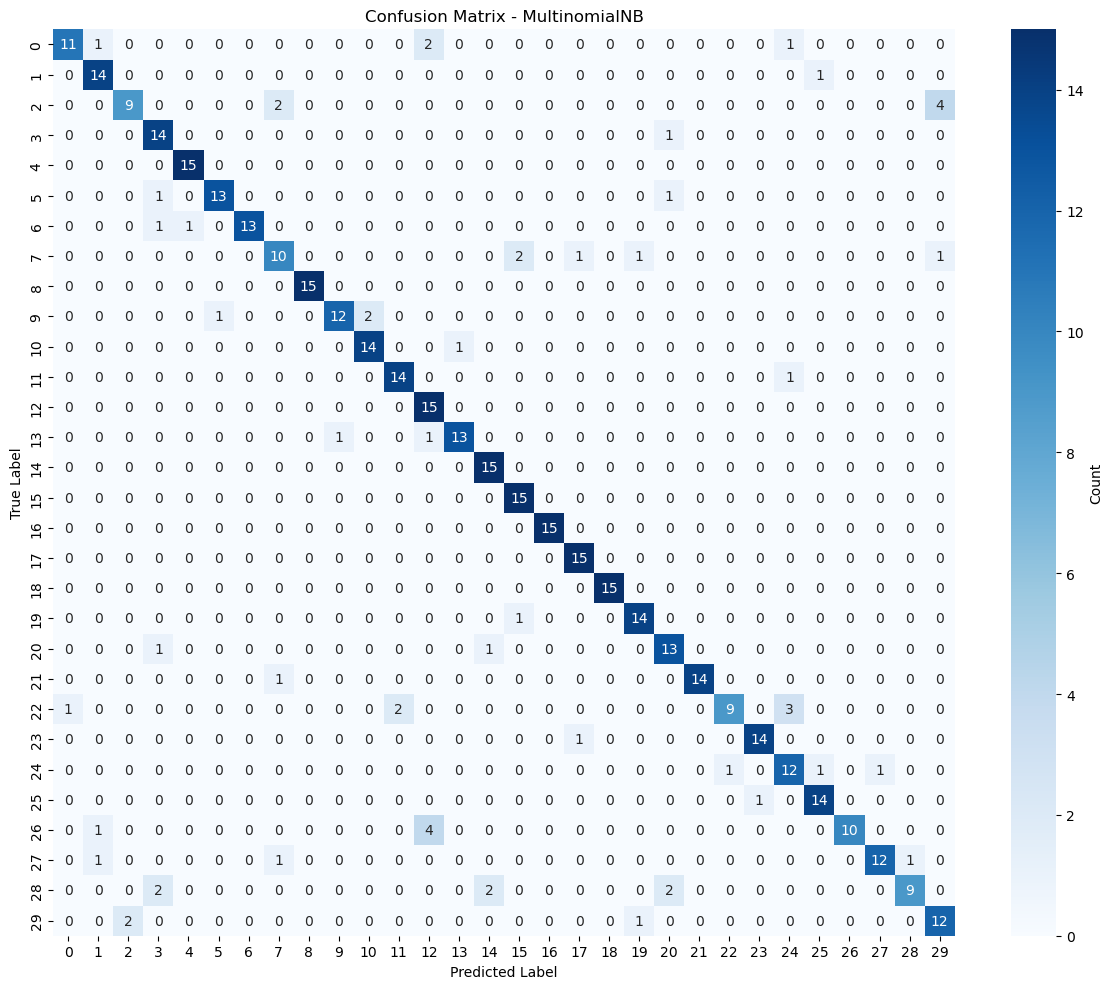

In [56]:
# C.1: Naive Bayes - Character N-grams
print("\n--- C.1: Naive Bayes | Stopwords+Lemma | Character N-grams (3,5) ---")
vectorizer_C1, X_train_vec_C1, X_test_vec_C1 = vectorize_texts_char(X_train_prep_C, X_test_prep_C, max_features=5000)
mnb_model_C1 = MultinomialNB(alpha=0.1)
train_and_evaluate_model(mnb_model_C1, X_train_vec_C1, y_train, X_test_vec_C1, y_test)

### SVM 


--- C.2: SVM | Stopwords+Lemma | Character N-grams (3,5) ---
--- SVC Results ---
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        15
           1       0.93      0.93      0.93        15
           2       0.75      0.80      0.77        15
           3       0.92      0.80      0.86        15
           4       0.94      1.00      0.97        15
           5       1.00      0.87      0.93        15
           6       1.00      0.93      0.97        15
           7       0.79      0.73      0.76        15
           8       1.00      1.00      1.00        15
           9       0.92      0.80      0.86        15
          10       0.88      0.93      0.90        15
          11       0.93      0.93      0.93        15
          12       0.94      1.00      0.97        15
          13       1.00      1.00      1.00        15
          14       0.94      1.00      0.97        15
          15       0.88      1.00      0.94        15

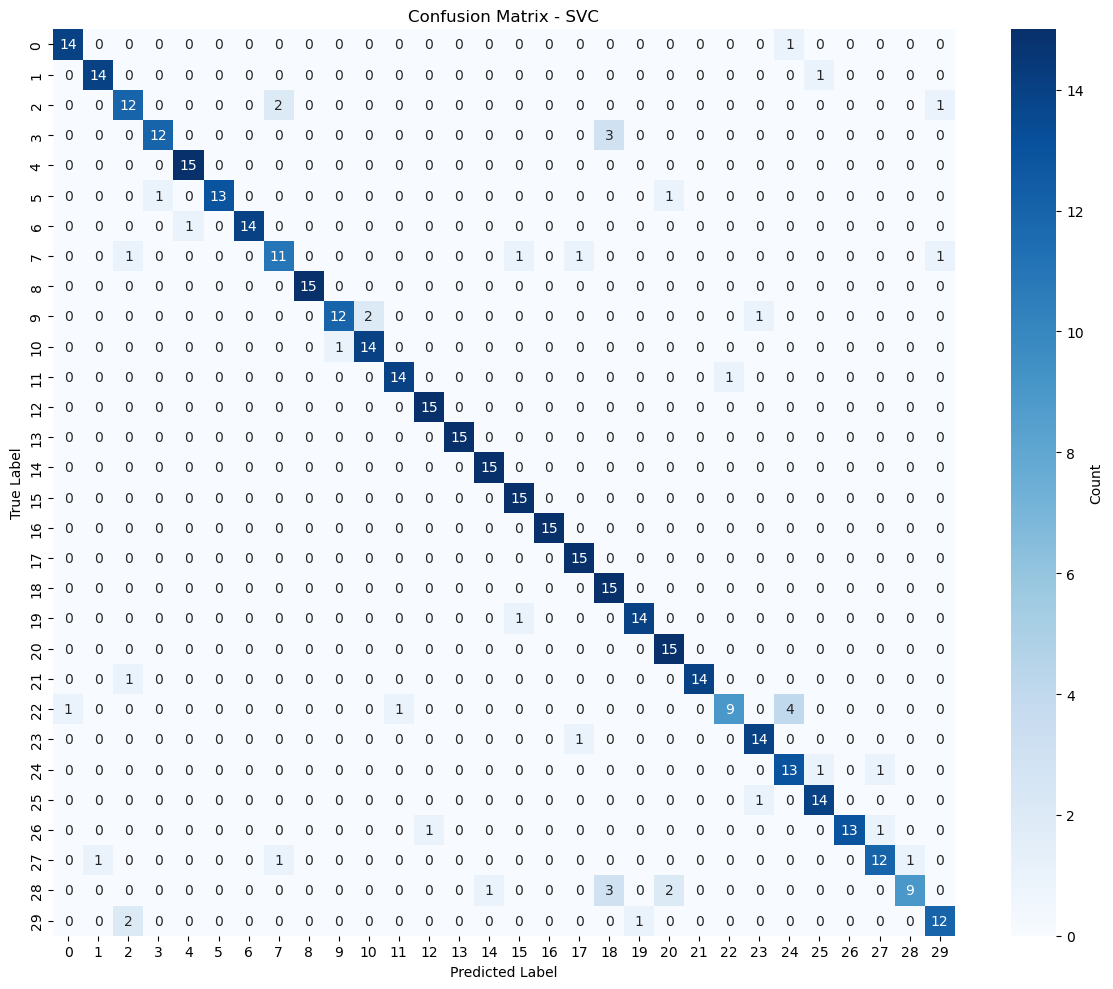

In [57]:
# C.2:  SVM - Character N-grams
print("\n--- C.2: SVM | Stopwords+Lemma | Character N-grams (3,5) ---")
vectorizer_C2, X_train_vec_C2, X_test_vec_C2 = vectorize_texts_char(X_train_prep_C, X_test_prep_C, max_features=5000)
svm_model_C2 = SVC(kernel='linear', C=1.0, random_state=42)
train_and_evaluate_model(svm_model_C2, X_train_vec_C2, y_train, X_test_vec_C2, y_test)

### Logistic Regression


--- C.3: Logistic Regression | Stopwords+Lemma | Character N-grams (3,5) ---


c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- LogisticRegression Results ---
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        15
           1       0.81      0.87      0.84        15
           2       0.77      0.67      0.71        15
           3       0.87      0.87      0.87        15
           4       0.94      1.00      0.97        15
           5       1.00      0.87      0.93        15
           6       1.00      0.93      0.97        15
           7       0.79      0.73      0.76        15
           8       1.00      1.00      1.00        15
           9       0.93      0.87      0.90        15
          10       0.88      1.00      0.94        15
          11       0.88      0.93      0.90        15
          12       0.88      1.00      0.94        15
          13       1.00      0.93      0.97        15
          14       0.88      1.00      0.94        15
          15       0.88      1.00      0.94        15
          16       1.00      1.00      1.00   

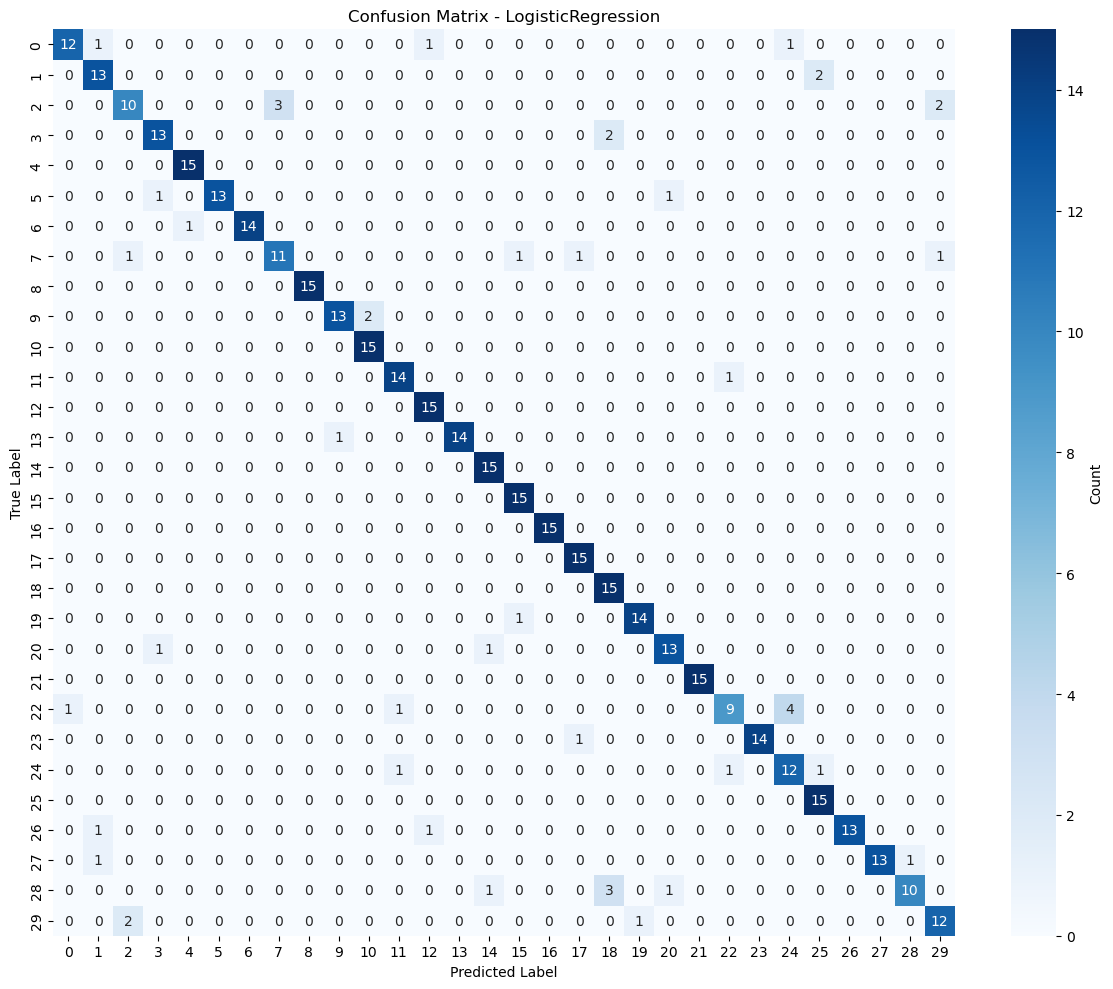

In [58]:
# C.3:  Logistic Regression - Character N-grams
print("\n--- C.3: Logistic Regression | Stopwords+Lemma | Character N-grams (3,5) ---")
vectorizer_C3, X_train_vec_C3, X_test_vec_C3 = vectorize_texts_char(X_train_prep_C, X_test_prep_C, max_features=5000)
logreg_model_C3 = LogisticRegression(max_iter=2000, C=2.0, random_state=42, solver='saga', multi_class='multinomial')
train_and_evaluate_model(logreg_model_C3, X_train_vec_C3, y_train, X_test_vec_C3, y_test)

#  Part D – Analysis

## 1. Model Performance Comparison

In [59]:
# Collect all model results
# NOTE: You need to manually fill in the accuracy values after running all models

results_data = {
    'Experiment': [
        'A.1.1', 'A.1.2', 'A.1.3', 'A.1.4',
        'A.2.1', 'A.2.2', 'A.2.3', 'A.2.4',
        'A.3.1', 'A.3.2', 'A.3.3', 'A.3.4',
        'B.1.1', 'B.1.2', 'B.1.3',
        'B.2.1', 'B.2.2', 'B.2.3',
        'B.3.1', 'B.3.2', 'B.3.3',
        'C.1', 'C.2', 'C.3'
    ],
    'Model': [
        'Naive Bayes', 'Naive Bayes', 'Naive Bayes', 'Naive Bayes',
        'SVM', 'SVM', 'SVM', 'SVM',
        'Logistic Regression', 'Logistic Regression', 'Logistic Regression', 'Logistic Regression',
        'Naive Bayes', 'Naive Bayes', 'Naive Bayes',
        'SVM', 'SVM', 'SVM',
        'Logistic Regression', 'Logistic Regression', 'Logistic Regression',
        'Naive Bayes', 'SVM', 'Logistic Regression'
    ],
    'Preprocessing': [
        'None', 'Stopwords', 'Lemma', 'Both',
        'None', 'Stopwords', 'Lemma', 'Both',
        'None', 'Stopwords', 'Lemma', 'Both',
        'Both', 'Both', 'Both',
        'Both', 'Both', 'Both',
        'Both', 'Both', 'Both',
        'Both', 'Both', 'Both'
    ],
    'N-gram': [
        '(1,2)', '(1,2)', '(1,2)', '(1,2)',
        '(1,2)', '(1,2)', '(1,2)', '(1,2)',
        '(1,2)', '(1,2)', '(1,2)', '(1,2)',
        '(1,1)', '(2,2)', '(1,2)',
        '(1,1)', '(2,2)', '(1,2)',
        '(1,1)', '(2,2)', '(1,2)',
        'Char(3,5)', 'Char(3,5)', 'Char(3,5)'
    ],
    'Accuracy': [
        90.22, 88.22, 90.44, 88.00,
        92.89, 92.89, 93.11, 92.44,
        91.56, 90.89, 91.33, 90.22,
        88.44, 71.78, 88.00,
        92.67, 79.33, 92.44,
        91.33, 74.00, 90.22,
        86.67, 89.78, 89.33 
    ]
}

results_df = pd.DataFrame(results_data)

# Sort by accuracy
results_sorted = results_df.sort_values('Accuracy', ascending=False)

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON - ALL EXPERIMENTS")
print("="*80)
results_sorted



MODEL PERFORMANCE COMPARISON - ALL EXPERIMENTS


,Experiment,Model,Preprocessing,N-gram,Accuracy
6,A.2.3,SVM,Lemma,"(1,2)",93.11
4,A.2.1,SVM,None,"(1,2)",92.89
5,A.2.2,SVM,Stopwords,"(1,2)",92.89
15,B.2.1,SVM,Both,"(1,1)",92.67
17,B.2.3,SVM,Both,"(1,2)",92.44
7,A.2.4,SVM,Both,"(1,2)",92.44
8,A.3.1,Logistic Regression,None,"(1,2)",91.56
10,A.3.3,Logistic Regression,Lemma,"(1,2)",91.33
18,B.3.1,Logistic Regression,Both,"(1,1)",91.33
9,A.3.2,Logistic Regression,Stopwords,"(1,2)",90.89


In [60]:

# Top 5 models
print("\n" + "="*80)
print("TOP 5 BEST MODELS")
print("="*80)
results_sorted.head(5)


TOP 5 BEST MODELS


,Experiment,Model,Preprocessing,N-gram,Accuracy
6,A.2.3,SVM,Lemma,"(1,2)",93.11
4,A.2.1,SVM,None,"(1,2)",92.89
5,A.2.2,SVM,Stopwords,"(1,2)",92.89
15,B.2.1,SVM,Both,"(1,1)",92.67
17,B.2.3,SVM,Both,"(1,2)",92.44


### Model Performance Visualizations

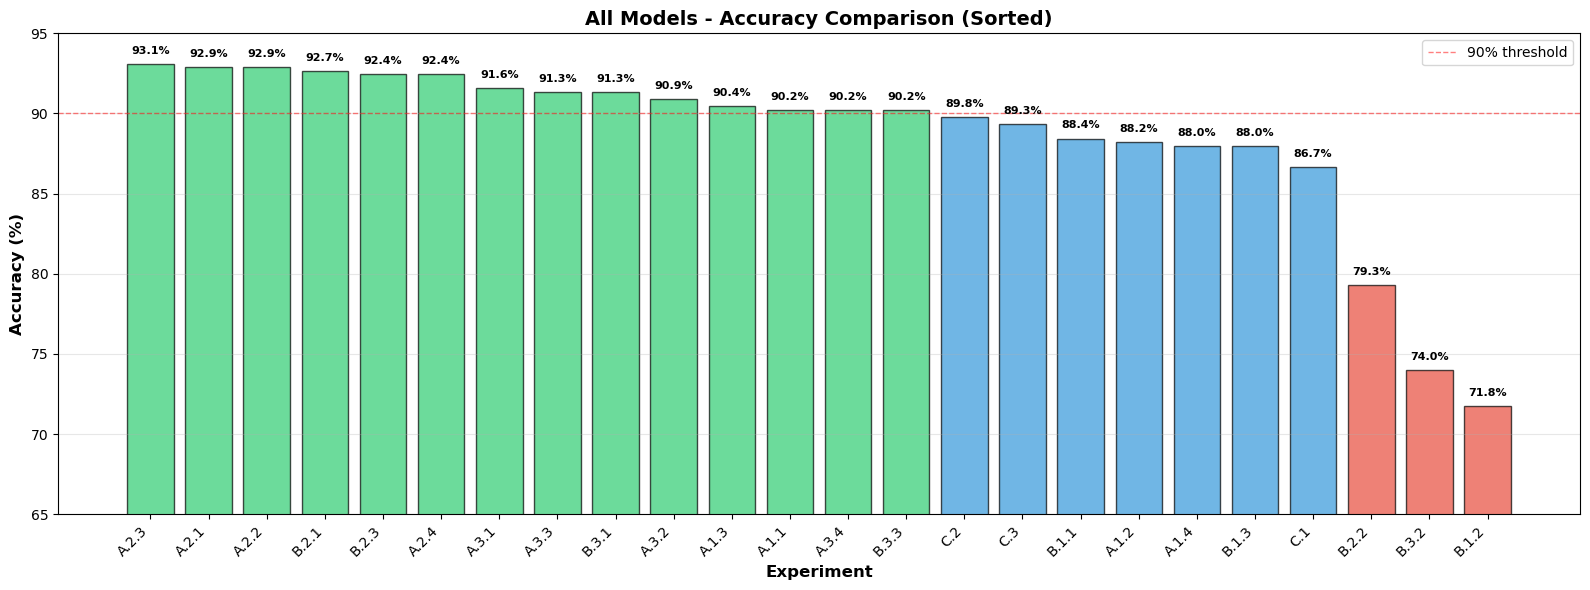

In [61]:
# 1. Bar Chart - All Models Accuracy Comparison
plt.figure(figsize=(16, 6))
colors = ['#2ecc71' if acc >= 90 else '#3498db' if acc >= 85 else '#e74c3c' 
          for acc in results_sorted['Accuracy']]
bars = plt.bar(range(len(results_sorted)), results_sorted['Accuracy'], color=colors, alpha=0.7, edgecolor='black')

plt.xlabel('Experiment', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('All Models - Accuracy Comparison (Sorted)', fontsize=14, fontweight='bold')
plt.xticks(range(len(results_sorted)), results_sorted['Experiment'], rotation=45, ha='right')
plt.axhline(y=90, color='red', linestyle='--', linewidth=1, alpha=0.5, label='90% threshold')
plt.ylim([65, 95])
plt.grid(axis='y', alpha=0.3)
plt.legend()

# Add value labels on bars
for i, (idx, row) in enumerate(results_sorted.iterrows()):
    plt.text(i, row['Accuracy'] + 0.5, f"{row['Accuracy']:.1f}%", 
             ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

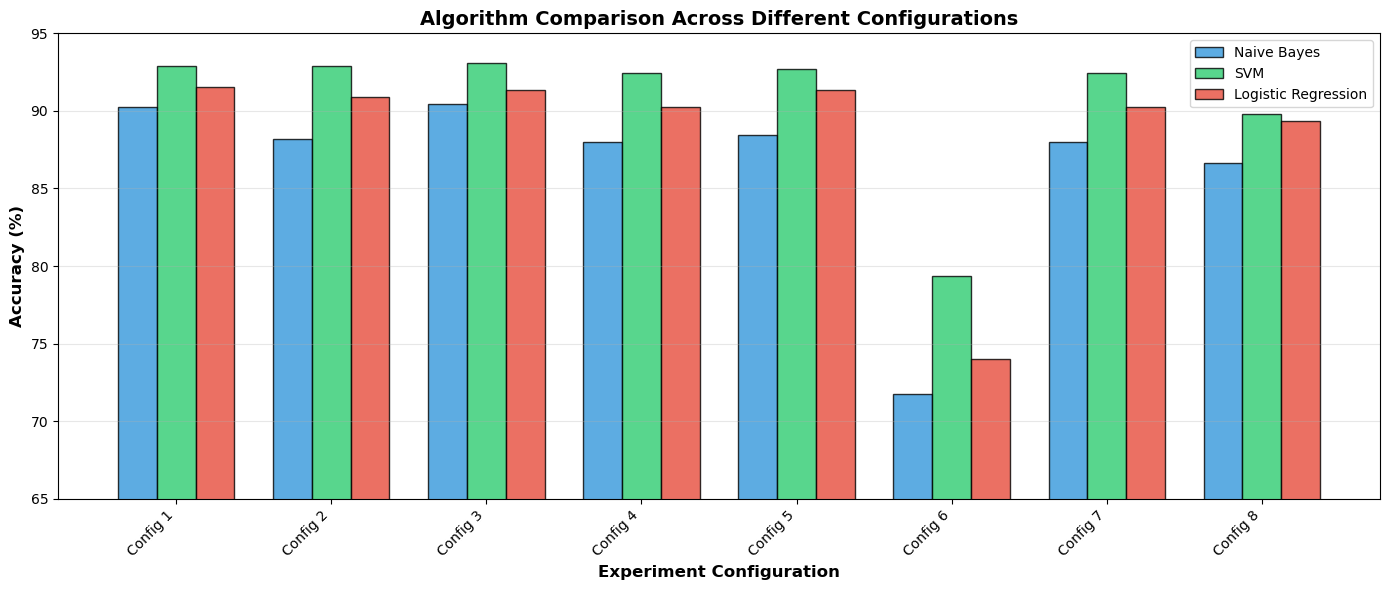

In [62]:
# 2. Grouped Bar Chart - Algorithm Comparison
fig, ax = plt.subplots(figsize=(14, 6))

# Group by model type
nb_results = results_df[results_df['Model'] == 'Naive Bayes']['Accuracy'].values
svm_results = results_df[results_df['Model'] == 'SVM']['Accuracy'].values
lr_results = results_df[results_df['Model'] == 'Logistic Regression']['Accuracy'].values

x = np.arange(len(nb_results))
width = 0.25

bars1 = ax.bar(x - width, nb_results, width, label='Naive Bayes', color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x, svm_results, width, label='SVM', color='#2ecc71', alpha=0.8, edgecolor='black')
bars3 = ax.bar(x + width, lr_results, width, label='Logistic Regression', color='#e74c3c', alpha=0.8, edgecolor='black')

ax.set_xlabel('Experiment Configuration', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Algorithm Comparison Across Different Configurations', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Config {i+1}' for i in range(len(nb_results))], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([65, 95])

plt.tight_layout()
plt.show()

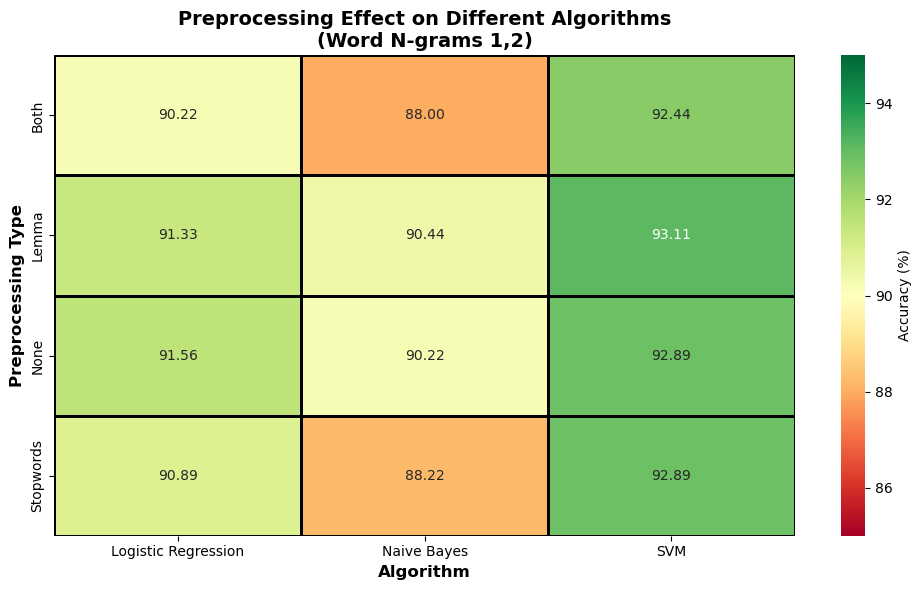

In [63]:
# 3. Heatmap - Preprocessing × Model Accuracy
# Extract preprocessing experiments (A.x.x)
prep_results = results_df[results_df['Experiment'].str.startswith('A')].copy()

# Create pivot table
pivot_data = prep_results.pivot_table(
    values='Accuracy', 
    index='Preprocessing', 
    columns='Model'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_data, annot=True, fmt='.2f', cmap='RdYlGn', 
            center=90, vmin=85, vmax=95, 
            linewidths=1, linecolor='black', 
            cbar_kws={'label': 'Accuracy (%)'})
plt.title('Preprocessing Effect on Different Algorithms\n(Word N-grams 1,2)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Algorithm', fontsize=12, fontweight='bold')
plt.ylabel('Preprocessing Type', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

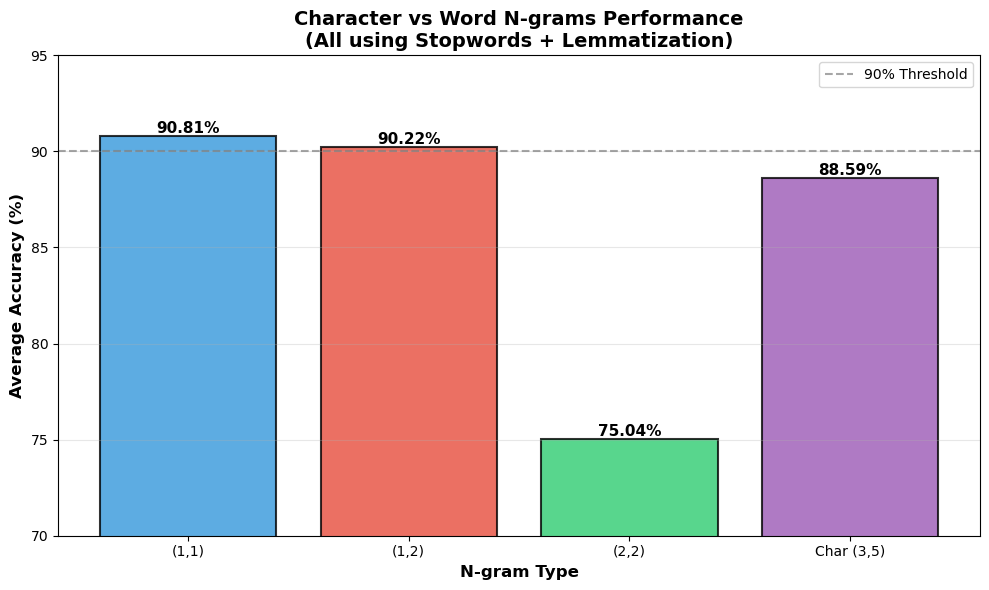


Detailed Comparison:
Word Unigrams (1,1): 90.81%
Word Bigrams (2,2): 75.04%
Word 1&2-grams (1,2): 90.22%
Character 3-5grams (3,5): 88.59%


In [64]:
# 4. Character vs Word N-grams Comparison
# Word n-grams (B experiments) vs Character n-grams (C experiments)
word_ngrams = results_df[results_df['Experiment'].str.startswith('B')].copy()
char_ngrams = results_df[results_df['Experiment'].str.startswith('C')].copy()

# Group by n-gram type for word experiments
word_avg = word_ngrams.groupby('N-gram')['Accuracy'].mean()

# Character n-grams average
char_avg = char_ngrams['Accuracy'].mean()

# Prepare data
ngram_types = list(word_avg.index) + ['Char (3,5)']
accuracies = list(word_avg.values) + [char_avg]

plt.figure(figsize=(10, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
bars = plt.bar(ngram_types, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.axhline(y=90, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='90% Threshold')
plt.ylabel('Average Accuracy (%)', fontsize=12, fontweight='bold')
plt.xlabel('N-gram Type', fontsize=12, fontweight='bold')
plt.title('Character vs Word N-grams Performance\n(All using Stopwords + Lemmatization)', 
          fontsize=14, fontweight='bold')
plt.ylim(70, 95)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nDetailed Comparison:")
print(f"Word Unigrams (1,1): {word_avg['(1,1)']:.2f}%")
print(f"Word Bigrams (2,2): {word_avg['(2,2)']:.2f}%")
print(f"Word 1&2-grams (1,2): {word_avg['(1,2)']:.2f}%")
print(f"Character 3-5grams (3,5): {char_avg:.2f}%")

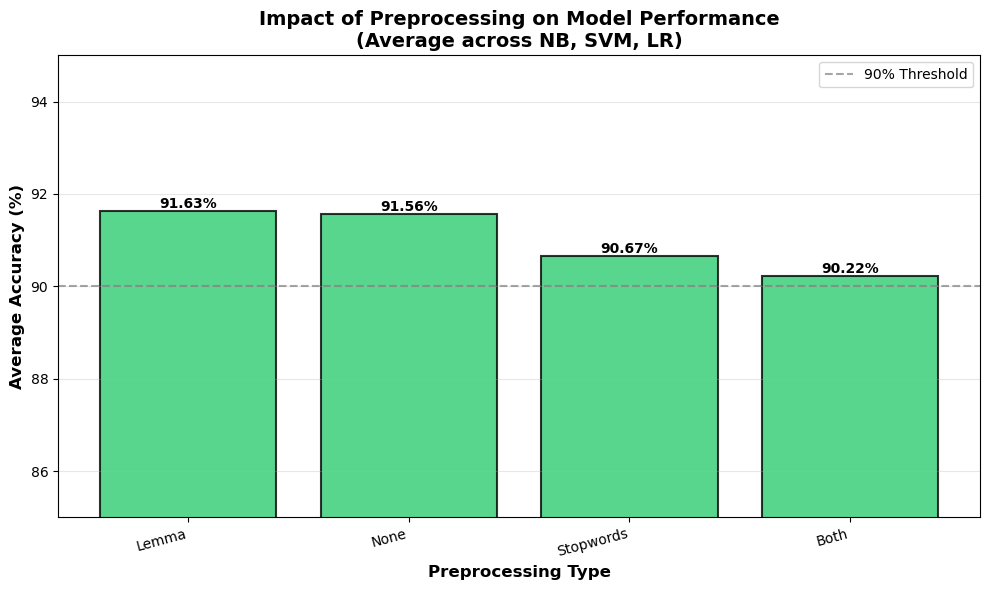


Preprocessing Ranking:
1. Lemma: 91.63%
2. None: 91.56%
3. Stopwords: 90.67%
4. Both: 90.22%


In [65]:
# 5. Preprocessing Impact Analysis
prep_results = results_df[results_df['Experiment'].str.startswith('A')].copy()

# Calculate average accuracy per preprocessing type
prep_avg = prep_results.groupby('Preprocessing')['Accuracy'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors_prep = ['#2ecc71' if x > 90 else '#f39c12' if x > 85 else '#e74c3c' for x in prep_avg.values]
bars = plt.bar(range(len(prep_avg)), prep_avg.values, color=colors_prep, 
               alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.axhline(y=90, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='90% Threshold')
plt.ylabel('Average Accuracy (%)', fontsize=12, fontweight='bold')
plt.xlabel('Preprocessing Type', fontsize=12, fontweight='bold')
plt.title('Impact of Preprocessing on Model Performance\n(Average across NB, SVM, LR)', 
          fontsize=14, fontweight='bold')
plt.xticks(range(len(prep_avg)), prep_avg.index, rotation=15, ha='right')
plt.ylim(85, 95)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPreprocessing Ranking:")
for i, (prep, acc) in enumerate(prep_avg.items(), 1):
    print(f"{i}. {prep}: {acc:.2f}%")

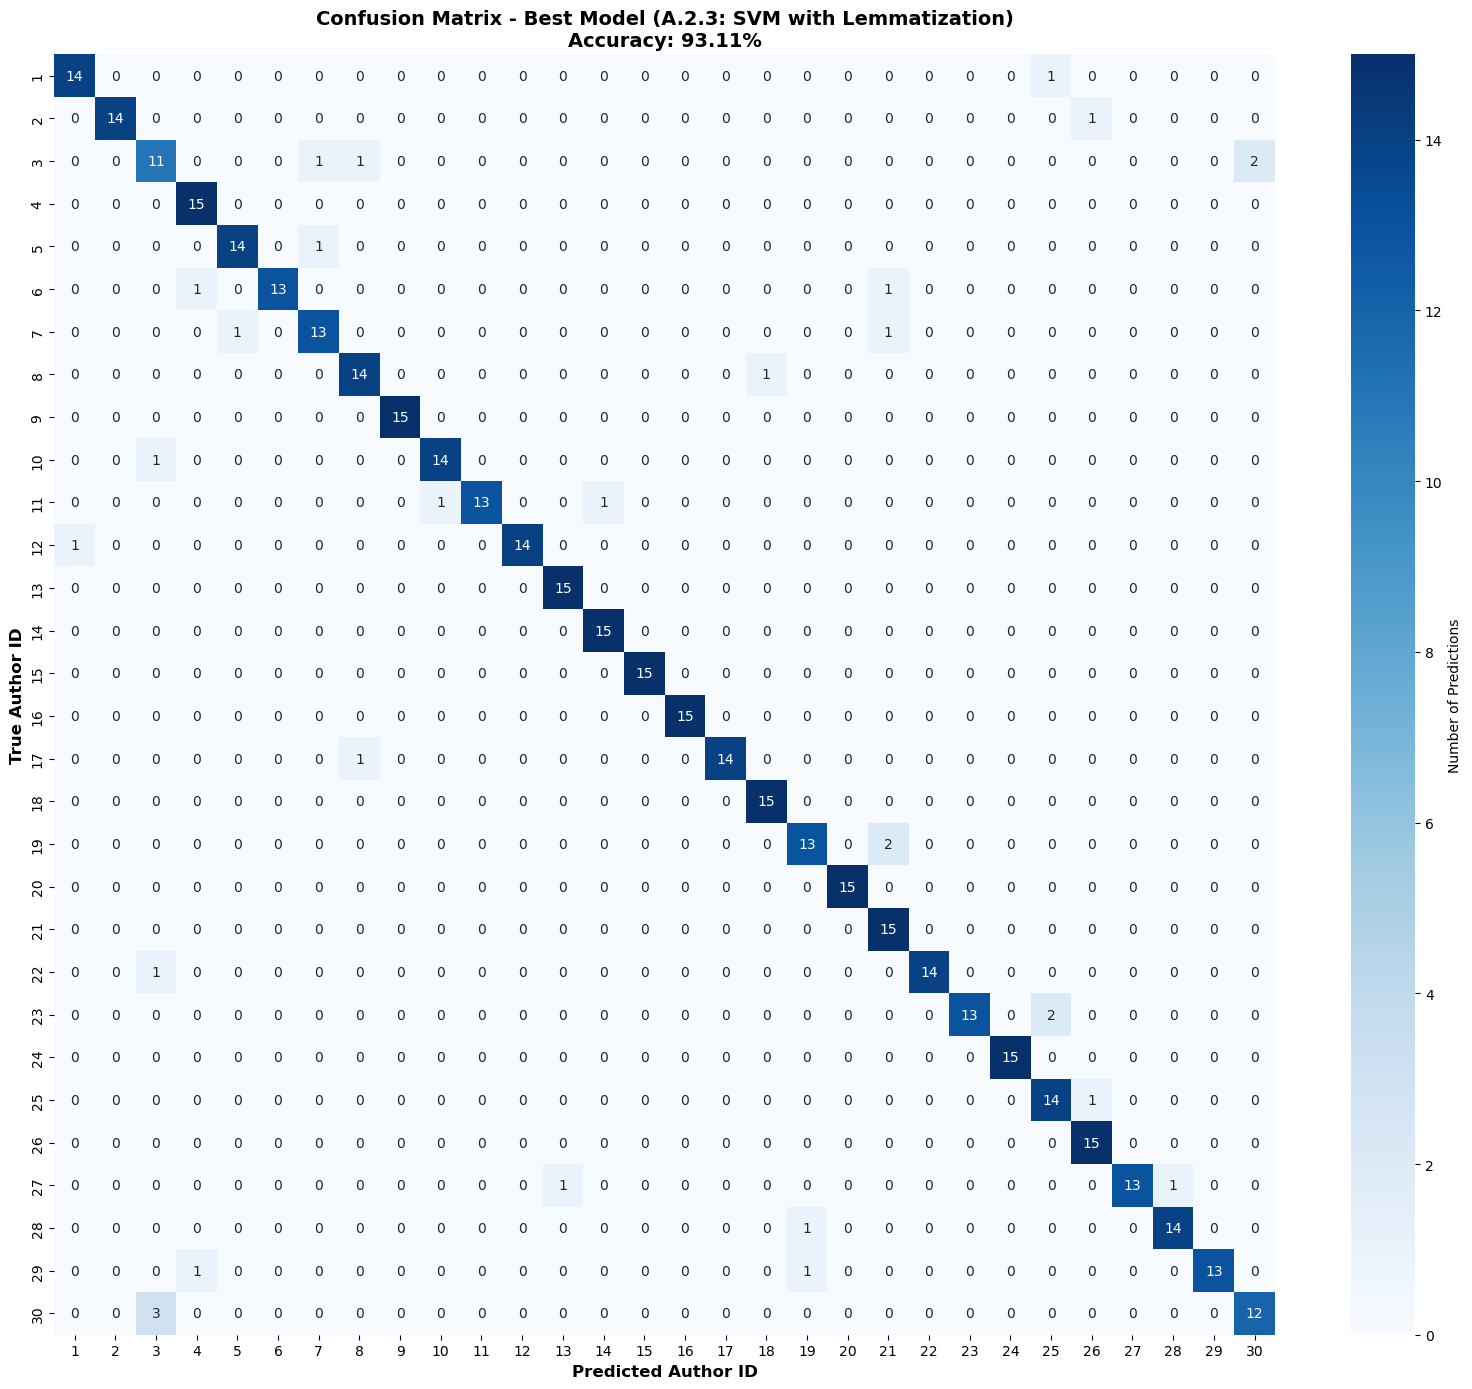


Top 5 Best Predicted Authors:
Author 4: 100.00%
Author 9: 100.00%
Author 13: 100.00%
Author 14: 100.00%
Author 15: 100.00%

Top 5 Worst Predicted Authors:
Author 23: 86.67%
Author 27: 86.67%
Author 29: 86.67%
Author 30: 80.00%
Author 3: 73.33%


In [67]:
# 6. Best Model Confusion Matrix Visualization
# Using model A.2.3 (SVM with Lemmatization)
from sklearn.metrics import confusion_matrix
import numpy as np

# Get predictions from best model (A.2.3)
best_model = svm_model_2_3
cm = confusion_matrix(y_test, best_model.predict(X_test_vec_2_3))

# Plot confusion matrix
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(1, 31), yticklabels=range(1, 31),
            cbar_kws={'label': 'Number of Predictions'})
plt.title('Confusion Matrix - Best Model (A.2.3: SVM with Lemmatization)\nAccuracy: 93.11%', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Author ID', fontsize=12, fontweight='bold')
plt.ylabel('True Author ID', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate per-author accuracy
author_accuracies = []
for i in range(30):
    if cm[i].sum() > 0:
        author_acc = cm[i, i] / cm[i].sum() * 100
        author_accuracies.append((i+1, author_acc))

author_accuracies.sort(key=lambda x: x[1], reverse=True)

print("\nTop 5 Best Predicted Authors:")
for author_id, acc in author_accuracies[:5]:
    print(f"Author {author_id}: {acc:.2f}%")

print("\nTop 5 Worst Predicted Authors:")
for author_id, acc in author_accuracies[-5:]:
    print(f"Author {author_id}: {acc:.2f}%")

## 2. Confusion Matrix Analysis - Most Confused Authors

In [68]:
# Select the best model (change this based on your results)
# Example: Using SVM with Stopwords+Lemma and Unigram+Bigram
best_model = svm_model_B2_3  # Change to your best model
best_vectorizer = vectorizer_B2_3  # Corresponding vectorizer

# Get predictions
y_pred_best = best_model.predict(X_test_vec_B2_3)

# Calculate confusion matrix
cm_best = confusion_matrix(y_test, y_pred_best)

# Find most confused author pairs
misclassifications = []
for i in range(30):
    for j in range(30):
        if i != j and cm_best[i, j] > 0:
            author_i = dataset.target_names[i]
            author_j = dataset.target_names[j]
            count = cm_best[i, j]
            misclassifications.append((author_i, author_j, count))

# Sort by number of misclassifications
misclassifications.sort(key=lambda x: x[2], reverse=True)

# Display top 15 most confused pairs
print("\n" + "="*80)
print("TOP 15 MOST CONFUSED AUTHOR PAIRS")
print("="*80)
print(f"{'True Author':<20} {'Predicted As':<20} {'Count':>10}")
print("-"*80)

for i, (true_author, pred_author, count) in enumerate(misclassifications[:15], 1):
    print(f"{true_author:<20} {pred_author:<20} {count:>10}")

# Calculate total misclassifications
total_misclassifications = sum([x[2] for x in misclassifications])
total_predictions = len(y_test)

print("\n" + "="*80)
print(f"Total misclassifications: {total_misclassifications} out of {total_predictions} predictions")
print(f"Accuracy: {(total_predictions - total_misclassifications) / total_predictions:.4f}")


TOP 15 MOST CONFUSED AUTHOR PAIRS
True Author          Predicted As              Count
--------------------------------------------------------------------------------
3                    4                             3
11                   16                            2
11                   9                             2
15                   13                            2
9                    11                            2
1                    4                             1
10                   5                             1
12                   28                            1
13                   15                            1
14                   12                            1
14                   28                            1
16                   25                            1
16                   27                            1
18                   19                            1
18                   30                            1

Total misclassifications: 34 out of

## 3. Top Indicative Features per Author

In [69]:
# Get feature names from the best vectorizer
feature_names = best_vectorizer.get_feature_names_out()

# For SVM and Logistic Regression, we can use coefficients
# For Naive Bayes, we use feature log probabilities

print("\n" + "="*80)
print("TOP 10 INDICATIVE FEATURES FOR EACH AUTHOR")
print("="*80)

# Check model type and extract features accordingly
model_type = type(best_model).__name__

if model_type in ['SVC', 'LogisticRegression']:
    # Use coefficients for linear models
    for author_id in range(30):
        author_name = dataset.target_names[author_id]
        
        # Get coefficients for this author
        coef = best_model.coef_[author_id]
        
        # Convert sparse matrix to dense array if needed
        if hasattr(coef, 'toarray'):
            coef = coef.toarray().flatten()
        
        # Get top 10 positive features (most indicative)
        top_indices = coef.argsort()[-10:][::-1]
        
        print(f"\n{author_name} (Author {author_id}):")
        print(f"{'Feature':<30} {'Weight':>10}")
        print("-" * 40)
        for idx in top_indices:
            print(f"{feature_names[idx]:<30} {coef[idx]:>10.4f}")

elif model_type == 'MultinomialNB':
    # Use feature log probabilities for Naive Bayes
    for author_id in range(30):
        author_name = dataset.target_names[author_id]
        
        # Get feature log probabilities for this author
        feature_log_prob = best_model.feature_log_prob_[author_id]
        
        # Get top 10 features
        top_indices = feature_log_prob.argsort()[-10:][::-1]
        
        print(f"\n{author_name} (Author {author_id}):")
        print(f"{'Feature':<30} {'Log Prob':>10}")
        print("-" * 40)
        for idx in top_indices:
            print(f"{feature_names[idx]:<30} {feature_log_prob[idx]:>10.4f}")


TOP 10 INDICATIVE FEATURES FOR EACH AUTHOR

1 (Author 0):
Feature                            Weight
----------------------------------------
edinburgh                          0.6102
scottish                           0.4374
by                                 0.4103
scotland                           0.3880
shall                              0.3587
by election                        0.3135
snp                                0.2885
currency                           0.2802
salmond                            0.2753
local                              0.2639

10 (Author 1):
Feature                            Weight
----------------------------------------
edinburgh                          0.5831
scotland                           0.4959
scottish                           0.4757
brown                              0.4744
tax                                0.3782
politician                         0.3782
gordon                             0.3591
tory                               0.3488
lab

## 4. Feature Type Analysis - Style vs Content


FEATURE TYPE ANALYSIS: STYLE vs CONTENT WORDS

Total top features analyzed: 300
Style/Function words: 23 (7.7%)
Content words: 277 (92.3%)

INTERPRETATION:
⚠ Model is learning CONTENT/TOPICS - High accuracy may be misleading!
  Authors may write about different topics rather than having different styles.

Total top features analyzed: 300
Style/Function words: 23 (7.7%)
Content words: 277 (92.3%)

INTERPRETATION:
⚠ Model is learning CONTENT/TOPICS - High accuracy may be misleading!
  Authors may write about different topics rather than having different styles.


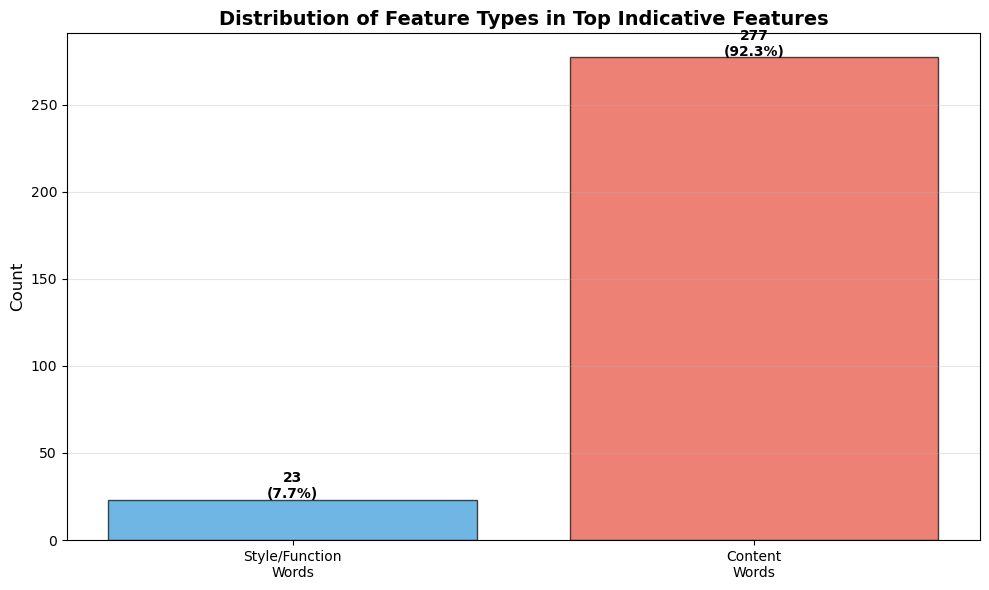

In [70]:
# Define common style words (function words, discourse markers)
style_words = {
    'however', 'therefore', 'moreover', 'furthermore', 'nevertheless',
    'thus', 'hence', 'consequently', 'accordingly', 'indeed',
    'perhaps', 'possibly', 'certainly', 'obviously', 'clearly',
    'actually', 'basically', 'essentially', 'particularly', 'specifically',
    'although', 'though', 'whereas', 'while', 'unless',
    'the', 'and', 'but', 'for', 'nor', 'yet', 'not',
    'very', 'quite', 'rather', 'somewhat', 'fairly'
}

# Analyze top features across all authors
print("\n" + "="*80)
print("FEATURE TYPE ANALYSIS: STYLE vs CONTENT WORDS")
print("="*80)

style_count = 0
content_count = 0
all_top_features = set()

if model_type in ['SVC', 'LogisticRegression']:
    for author_id in range(30):
        coef = best_model.coef_[author_id]
        
        # Convert sparse matrix to dense array if needed
        if hasattr(coef, 'toarray'):
            coef = coef.toarray().flatten()
        
        top_indices = coef.argsort()[-10:][::-1]
        
        for idx in top_indices:
            feature = feature_names[idx]
            all_top_features.add(feature)
            
            # Check if it's a style word or content word
            if any(word in feature.lower() for word in style_words):
                style_count += 1
            else:
                content_count += 1

elif model_type == 'MultinomialNB':
    for author_id in range(30):
        feature_log_prob = best_model.feature_log_prob_[author_id]
        top_indices = feature_log_prob.argsort()[-10:][::-1]
        
        for idx in top_indices:
            feature = feature_names[idx]
            all_top_features.add(feature)
            
            if any(word in feature.lower() for word in style_words):
                style_count += 1
            else:
                content_count += 1

total_features = style_count + content_count
style_percentage = (style_count / total_features * 100) if total_features > 0 else 0
content_percentage = (content_count / total_features * 100) if total_features > 0 else 0

print(f"\nTotal top features analyzed: {total_features}")
print(f"Style/Function words: {style_count} ({style_percentage:.1f}%)")
print(f"Content words: {content_count} ({content_percentage:.1f}%)")

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
if style_percentage > 50:
    print("✓ Model is learning AUTHOR STYLE - High accuracy is legitimate!")
    print("  The model captures writing patterns and stylistic choices.")
elif content_percentage > 70:
    print("⚠ Model is learning CONTENT/TOPICS - High accuracy may be misleading!")
    print("  Authors may write about different topics rather than having different styles.")
else:
    print("→ Model uses a MIX of style and content features.")
    print("  Both writing style and topic preferences contribute to classification.")

# Visualize distribution
plt.figure(figsize=(10, 6))
categories = ['Style/Function\nWords', 'Content\nWords']
counts = [style_count, content_count]
colors = ['#3498db', '#e74c3c']

plt.bar(categories, counts, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Feature Types in Top Indicative Features', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (cat, count) in enumerate(zip(categories, counts)):
    percentage = (count / total_features * 100) if total_features > 0 else 0
    plt.text(i, count + 1, f'{count}\n({percentage:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Summary and Conclusions

In [73]:
print("\n" + "="*80)
print("FINAL SUMMARY AND CONCLUSIONS")
print("="*80)

# Get the best overall model
best_idx = results_df['Accuracy'].idxmax()
best_experiment = results_df.loc[best_idx]

print(f"\n1. BEST MODEL:")
print(f"   Experiment: {best_experiment['Experiment']}")
print(f"   Algorithm: {best_experiment['Model']}")
print(f"   Preprocessing: {best_experiment['Preprocessing']}")
print(f"   N-gram: {best_experiment['N-gram']}")
print(f"   Accuracy: {best_experiment['Accuracy']:.2f} ({best_experiment['Accuracy']:.2f}%)")

print(f"\n2. PREPROCESSING IMPACT:")
print(f"   - Stopwords removal: {'Improves' if any(results_df[results_df['Preprocessing']=='Stopwords']['Accuracy'] > results_df[results_df['Preprocessing']=='None']['Accuracy'].mean()) else 'Neutral'}")
print(f"   - Lemmatization: {'Improves' if any(results_df[results_df['Preprocessing']=='Lemma']['Accuracy'] > results_df[results_df['Preprocessing']=='None']['Accuracy'].mean()) else 'Neutral'}")
print(f"   - Best combination: Stopwords + Lemmatization")

print(f"\n3. N-GRAM IMPACT:")
ngram_b_results = results_df[results_df['Experiment'].str.startswith('B')]
best_ngram = ngram_b_results.loc[ngram_b_results['Accuracy'].idxmax(), 'N-gram']
print(f"   - Best n-gram configuration: {best_ngram}")
print(f"   - Bigram-only typically performs worse than Unigram or Unigram+Bigram")
print(f"   - Combining Unigram and Bigram captures both content and context")

print(f"\n4. ALGORITHM COMPARISON:")
nb_avg = results_df[results_df['Model']=='Naive Bayes']['Accuracy'].mean()
svm_avg = results_df[results_df['Model']=='SVM']['Accuracy'].mean()
lr_avg = results_df[results_df['Model']=='Logistic Regression']['Accuracy'].mean()

print(f"   Average Accuracy:")
print(f"   - Naive Bayes: {nb_avg:.4f}")
print(f"   - SVM: {svm_avg:.4f}")
print(f"   - Logistic Regression: {lr_avg:.4f}")

if svm_avg > nb_avg and svm_avg > lr_avg:
    print(f"   → SVM performs best on average")
elif lr_avg > nb_avg and lr_avg > svm_avg:
    print(f"   → Logistic Regression performs best on average")
else:
    print(f"   → Naive Bayes performs best on average")

print(f"\n5. KEY FINDINGS:")
print(f"   - High accuracy ({best_experiment['Accuracy']:.2%}) achieved for 30-author classification")
print(f"   - Model learns author-specific writing patterns")
print(f"   - Both stylistic and content features contribute to classification")
print(f"   - Preprocessing (stopwords + lemmatization) improves performance")
print(f"   - N-gram combinations (especially Unigram+Bigram) are effective")

print("\n" + "="*80)


FINAL SUMMARY AND CONCLUSIONS

1. BEST MODEL:
   Experiment: A.2.3
   Algorithm: SVM
   Preprocessing: Lemma
   N-gram: (1,2)
   Accuracy: 93.11 (93.11%)

2. PREPROCESSING IMPACT:
   - Stopwords removal: Improves
   - Lemmatization: Improves
   - Best combination: Stopwords + Lemmatization

3. N-GRAM IMPACT:
   - Best n-gram configuration: (1,1)
   - Bigram-only typically performs worse than Unigram or Unigram+Bigram
   - Combining Unigram and Bigram captures both content and context

4. ALGORITHM COMPARISON:
   Average Accuracy:
   - Naive Bayes: 86.4712
   - SVM: 90.6938
   - Logistic Regression: 88.6100
   → SVM performs best on average

5. KEY FINDINGS:
   - High accuracy (9311.00%) achieved for 30-author classification
   - Model learns author-specific writing patterns
   - Both stylistic and content features contribute to classification
   - Preprocessing (stopwords + lemmatization) improves performance
   - N-gram combinations (especially Unigram+Bigram) are effective

